In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%reload_ext autoreload
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import sys
from ipywidgets import interactive, FloatSlider, interact, fixed
from divtel import *
from adjustText import adjust_text

import copy
import astropy.units as u
from astropy.coordinates import SkyCoord

from astroplan.plots import plot_sky
from astroplan import FixedTarget
#from . import utils
#from .const import COLORS
#from . import pointing

from matplotlib.transforms import Affine2D
from astropy.visualization.wcsaxes import SphericalCircle

import healpy as hp
import tqdm

#!jupyter labextension install @jupyter-widgets/jupyterlab-manager

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## LOAD CTA CONFIG

In [2]:
cta = CTA_Info('south')

Observer         :  CTA South
Location         :  Paranal , (1946.635798, -5467.63394562, -2642.49852123) km
Observation time :  2025-03-12T13:40:43.944


In [3]:
array_MST = LoadConfig("/Users/macbook/divtel/Paranal_Only_MST.txt", frame=cta)

In [4]:

array_SST = LoadConfig("/Users/macbook/divtel/Paranal_Only_SST.txt", frame=cta)

In [5]:
array_MST_and_SST =LoadConfig("/Users/macbook/divtel/MST_and_SST.txt", frame=cta)

In [6]:
array_MST.table.units = "deg"
array_MST.table
array_SST.table.units ="deg"

In [7]:
def compute_center_of_gravity(group):
    x, y, z = group['x'], group['y'], group['z']
    cog_x = round(np.mean(x),2)
    cog_y = round(np.mean(y),2)
    cog_z = round(np.mean(z),2)
    return cog_x, cog_y, cog_z

# Function to create new telescope list with center of gravity
def create_new_group_list(tel_group):
    new_telescopes = []
    for group in tel_group.groups:
        print(tel_group.groups)
        print (group['focal'][0],round(group['radius'][0],2))
        #id_ = group["id"][0]
        cog = compute_center_of_gravity(group)
        focal, fov = group['focal'][0], round(group['radius'][0],2)  # Assuming same within a group
        new_telescopes.append([*cog, focal, fov])
    return new_telescopes


In [8]:
array_MST.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,0.0,24.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,22.65
2,0.0,151.0,25.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,152.67
3,0.0,-151.0,31.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,152.68
4,150.0,75.0,21.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,188.09
5,150.0,-75.0,26.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,187.98
6,150.0,240.0,24.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,295.50
7,150.0,-240.0,30.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,295.49
8,313.0,0.0,19.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,335.47


In [9]:
array_SST.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,199.0,0.0,16.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,200.19
2,-230.0,0.0,22.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,229.36
3,-249.0,-325.0,40.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,409.12
4,-249.0,325.0,17.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,409.16
5,-249.0,-577.0,54.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,628.62
6,-249.0,577.0,8.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,628.51
7,-220.0,-797.0,68.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,827.51
8,-220.0,797.0,10.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,826.84


## Choosing the different configurations

In [10]:
sub_groups_MST={'1':[3,4,7], 
            '2': [1,9,12,14],
            '3': [10,11,13], 
             '4': [2,6,8,5]}
sub_groups_SST = {'1':[24,12,30,42,8,18], 
             '2':[44,32,34],
              '3':[43,33,35],
              '4':[23,41,29,11,7,17],
              '5':[37,39,45],
              '6':[38,40,46],
              '7':[1,2,9,10],
              '8':[16,26,28],
              '9':[15,25,27],
              '10':[13,14,36],
              '11':[5,19,21],
              '12':[6,20,22],
              '13':[3,4,31]}



In [11]:
tel_group, labels, number_of_telescopes_subarray_1 =array_MST.group_by(sub_groups_MST)

In [12]:
tel_group_SST, labels_SST, number_of_telescopes_config_SST =array_SST.group_by(sub_groups_SST)

In [13]:
new_telescopes = create_new_group_list(tel_group)

<TableGroups indices=[ 0  3  7 10 14]>
16.0 3.85
<TableGroups indices=[ 0  3  7 10 14]>
16.0 3.85
<TableGroups indices=[ 0  3  7 10 14]>
16.0 3.85
<TableGroups indices=[ 0  3  7 10 14]>
16.0 3.85


In [14]:
new_telescopes_SST = create_new_group_list(tel_group_SST)

<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45
<TableGroups indices=[ 0  6  9 12 18 21 24 28 31 34 37 40 43 46]>
5.6 4.45


In [15]:
for telescope in new_telescopes:
    print(telescope)

[100.0, -105.33, 27.33, 16.0, 3.85]
[-153.25, 81.75, 27.38, 16.0, 3.85]
[-204.33, -109.0, 33.83, 16.0, 3.85]
[153.25, 79.0, 23.5, 16.0, 3.85]


In [16]:
for telescope in new_telescopes_SST:
    print(telescope)

[0.0, 816.83, 21.83, 5.6, 4.45]
[-840.0, 404.67, 16.75, 5.6, 4.45]
[-840.0, -404.67, 55.92, 5.6, 4.45]
[0.0, -816.83, 65.42, 5.6, 4.45]
[839.67, -404.67, 17.75, 5.6, 4.45]
[839.67, 404.67, 10.08, 5.6, 4.45]
[-7.75, 0.0, 22.5, 5.6, 4.45]
[415.67, 402.0, 12.42, 5.6, 4.45]
[415.67, -402.0, 27.92, 5.6, 4.45]
[429.33, 0.0, 16.08, 5.6, 4.45]
[-415.67, -402.0, 48.25, 5.6, 4.45]
[-415.67, 402.0, 15.58, 5.6, 4.45]
[-429.67, 0.0, 29.42, 5.6, 4.45]


In [17]:
# Define the file path where you want to save the output
output_file_path = './best_configuration_MST.txt'

# Open the file in write mode
with open(output_file_path, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
    for i, telescope in enumerate(new_telescopes):
        # Assuming telescope is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        # Write the data to the file
        #print(values)
        file.write(f"{values}\n")

print(f"New telescope data has been written to {output_file_path}")


New telescope data has been written to ./best_configuration_MST.txt


In [18]:
# Define the file path where you want to save the output
output_file_path = './best_configuration_SST.txt'

# Open the file in write mode
with open(output_file_path, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
    for i, telescope in enumerate(new_telescopes_SST):
        # Assuming telescope is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        # Write the data to the file
        #print(values)
        file.write(f"{values}\n")

print(f"New telescope data has been written to {output_file_path}")


New telescope data has been written to ./best_configuration_SST.txt


In [19]:
combination_MST_SST = LoadConfig("/Users/macbook/divtel/MST_and_SST.txt", frame=cta)

In [20]:
config_MST = LoadConfig("/Users/macbook/divtel/best_configuration_MST.txt",complete_array=combination_MST_SST, frame=cta)
config_SST = LoadConfig("/Users/macbook/divtel/best_configuration_SST.txt", complete_array=combination_MST_SST, frame=cta)
full_array_config_SST = LoadConfig("/Users/macbook/divtel/best_configuration_SST.txt", frame=cta)


In [21]:
config_MST.table.units= "deg"

In [22]:
config_MST.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,100.0,-105.33,27.33,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,149.29
2,-153.25,81.75,27.38,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,168.62
3,-204.33,-109.0,33.83,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,226.55
4,153.25,79.0,23.5,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,177.67


In [23]:
config_SST.table.units = "deg"

In [24]:
config_SST.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,816.83,21.83,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,816.88
2,-840.0,404.67,16.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,927.27
3,-840.0,-404.67,55.92,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,927.57
4,0.0,-816.83,65.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,817.65
5,839.67,-404.67,17.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,937.38
6,839.67,404.67,10.08,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,937.50
7,-7.75,0.0,22.5,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,6.97
8,415.67,402.0,12.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,582.67


In [25]:
div_stop=[]

div_stop=np.linspace(0,0.03, 10)


In [26]:
FoV_array_MST=[]#This will be the one without saturation
multiplicity_array_MST=[] #This will be the one without saturation

for div in div_stop:
    config_MST.divergent_pointing(div, complete_array=combination_MST_SST, az=0,alt=70)    
    FoV_array_MST=config_MST.hFoV(subarray_mult=number_of_telescopes_subarray_1)[0]
    multiplicity_array_MST=config_MST.hFoV(subarray_mult=number_of_telescopes_subarray_1)[1]



4it [00:00,  5.63it/s]
4it [00:00,  6.24it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


4it [00:00,  5.95it/s]
4it [00:00,  6.92it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


4it [00:00,  6.44it/s]
4it [00:00,  5.97it/s]


...

4it [00:00,  6.70it/s]
4it [00:00,  6.02it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


4it [00:00,  6.30it/s]
4it [00:00,  6.65it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


4it [00:00,  6.80it/s]
4it [00:00,  6.10it/s]


In [27]:
FoV_array_SST=[]#This will be the one without saturation
multiplicity_array_SST=[] #This will be the one without saturation

for div in div_stop:
    config_SST.divergent_pointing(div,complete_array=combination_MST_SST, az=0,alt=70)    
    FoV_array_SST=config_SST.hFoV(subarray_mult=number_of_telescopes_config_SST)[0]
    multiplicity_array_SST=config_SST.hFoV(subarray_mult=number_of_telescopes_config_SST)[1]


13it [00:02,  5.31it/s]
13it [00:02,  6.46it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


13it [00:01,  6.79it/s]
13it [00:01,  6.90it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


13it [00:02,  6.36it/s]
13it [00:01,  6.68it/s]


...

13it [00:01,  6.83it/s]
13it [00:01,  6.89it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


13it [00:01,  6.60it/s]
13it [00:01,  6.85it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


13it [00:02,  6.34it/s]
13it [00:01,  6.82it/s]


4it [00:00,  6.80it/s]
4it [00:00,  6.24it/s]


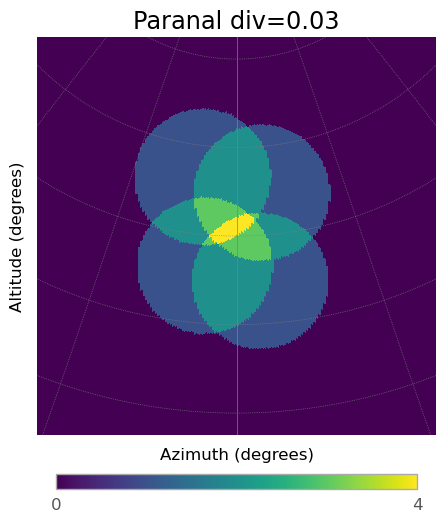

In [28]:
config_MST.multiplicity_plot()

In [29]:
table_SST_conv = []
table_SST= config_SST.table
number_of_telescopes_config_SST_first_half=[]
# Append the columns for LST so I know what to get or expect
table_SST_conv.append(table_SST['x'])
table_SST_conv.append(table_SST['y'])
table_SST_conv.append(table_SST['z'])
table_SST_conv.append(table_SST['focal'])
table_SST_conv.append(table_SST['radius'])
table_SST_conv.append(table_SST['fov'])

# Initialize sub_config and other variables
sub_config = []
telescopes = [1, 2,3,4,5,6]  # Telescope indices
# Loop through the telescopes so I can write them in a file
for tel in telescopes:
    # Putting it tel-1 because the first column we had the index
    sub_config.append([col[tel - 1] for col in table_SST_conv])
    number_of_telescopes_config_SST_first_half.append(number_of_telescopes_config_SST[tel-1])


# Print the result for verification
print(sub_config)
print(number_of_telescopes_config_SST_first_half)

[[0.0, 816.83, 21.83, 5.6, 4.450000000000001, 62.46242685852285], [-840.0, 404.67, 16.75, 5.6, 4.450000000000001, 62.46242685852285], [-840.0, -404.67, 55.92, 5.6, 4.450000000000001, 62.46242685852285], [0.0, -816.83, 65.42, 5.6, 4.450000000000001, 62.46242685852285], [839.67, -404.67, 17.75, 5.6, 4.450000000000001, 62.46242685852285], [839.67, 404.67, 10.08, 5.6, 4.450000000000001, 62.46242685852285]]
[6, 3, 3, 6, 3, 3]


In [30]:
table_SST_div = []
table_SST= config_SST.table
number_of_telescopes_config_SST_second_half=[]
# Append the columns for LST so I know what to get or expect
table_SST_div.append(table_SST['x'])
table_SST_div.append(table_SST['y'])
table_SST_div.append(table_SST['z'])
table_SST_div.append(table_SST['focal'])
table_SST_div.append(table_SST['radius'])
table_SST_div.append(table_SST['fov'])

# Initialize sub_config and other variables
sub_config_div= []
telescopes = [7,8,9,10,11,12,13]  # Telescope indices
# Loop through the telescopes so I can write them in a file
for tel in telescopes:
    # Adjust for 1-based indexing in telescopes to 0-based indexing in Python
    sub_config_div.append([col[tel - 1] for col in table_SST_div])
    number_of_telescopes_config_SST_second_half.append(number_of_telescopes_config_SST[tel-1])


# Print the result for verification
print(sub_config_div)
print(number_of_telescopes_config_SST_second_half)

[[-7.75, 0.0, 22.5, 5.6, 4.450000000000001, 62.46242685852285], [415.67, 402.0, 12.42, 5.6, 4.450000000000001, 62.46242685852285], [415.67, -402.0, 27.92, 5.6, 4.450000000000001, 62.46242685852285], [429.33, 0.0, 16.08, 5.6, 4.450000000000001, 62.46242685852285], [-415.67, -402.0, 48.25, 5.6, 4.450000000000001, 62.46242685852285], [-415.67, 402.0, 15.58, 5.6, 4.450000000000001, 62.46242685852285], [-429.67, 0.0, 29.42, 5.6, 4.450000000000001, 62.46242685852285]]
[4, 3, 3, 3, 3, 3, 3]


In [31]:
# Define the file path where you want to save the output
output_file_path_3 = './best_SST_conv_for_comb_MST.txt'

# Open the file in write mode
with open(output_file_path_3, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
   for telescope in sub_config:
        # Assuming each telescope in sub_config is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        file.write(f"{values}\n")  # Write each row of telescope data

print(f"New telescope data has been written to {output_file_path_3}")
# Define the file path where you want to save the output
output_file_path_4 = './best_SST_div_for_comb_MST.txt'

# Open the file in write mode
with open(output_file_path_4, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
   for telescope in sub_config_div:
        # Assuming each telescope in sub_config is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        file.write(f"{values}\n")  # Write each row of telescope data

print(f"New telescope data has been written to {output_file_path_4}")

New telescope data has been written to ./best_SST_conv_for_comb_MST.txt
New telescope data has been written to ./best_SST_div_for_comb_MST.txt


In [32]:
SST_config_conv= LoadConfig('./best_SST_conv_for_comb_MST.txt', complete_array=combination_MST_SST,frame=cta, pointing2src=True)
SST_config_div=LoadConfig('./best_SST_div_for_comb_MST.txt',complete_array=combination_MST_SST, frame=cta, pointing2src=True)

In [33]:
SST_config_conv.table.units= "deg"
SST_config_div.table.units= "deg"

In [34]:
SST_config_conv.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,816.83,21.83,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,816.88
2,-840.0,404.67,16.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,927.27
3,-840.0,-404.67,55.92,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,927.57
4,0.0,-816.83,65.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,817.65
5,839.67,-404.67,17.75,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,937.38
6,839.67,404.67,10.08,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,937.50


In [35]:
SST_config_div.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-7.75,0.0,22.5,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,6.97
2,415.67,402.0,12.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,582.67
3,415.67,-402.0,27.92,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,582.43
4,429.33,0.0,16.08,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,435.31
5,-415.67,-402.0,48.25,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,574.43
6,-415.67,402.0,15.58,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,574.28
7,-429.67,0.0,29.42,0.000,0.000,90.000,5.600,4.450,62.462,1.000,-0.000,0.000,423.89


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2216827201668319 rad
-0.0 rad
1.1763223046176035 rad
-0.1124742730126779 rad
1.1769605216392005 rad
0.1124742730126779 rad
1.177361939363254 rad
-0.0 rad
1.2618787640987428 rad
0.1463222010203255 rad
1.260779754735134 rad
-0.1463222010203255 rad
1.2658267601312228 rad
-0.0 rad


6it [00:00,  6.65it/s]
7it [00:01,  6.40it/s]
6it [00:00,  6.31it/s]


12.638613958578553


7it [00:01,  6.66it/s]


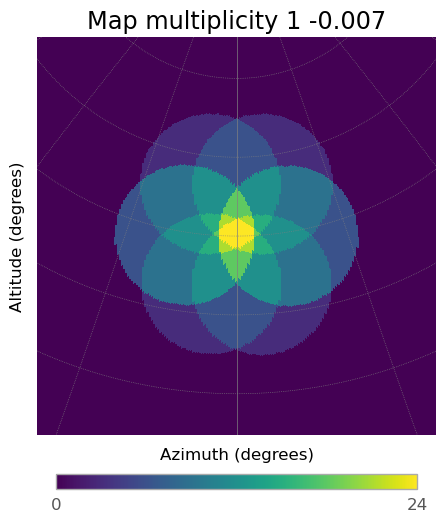

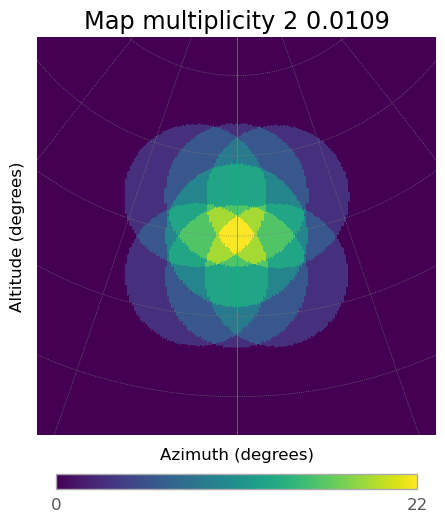

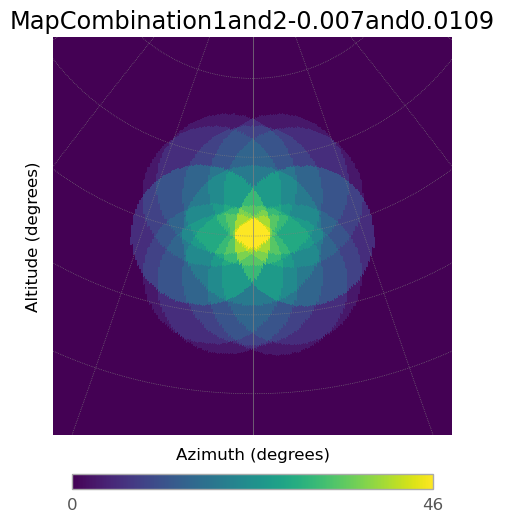

In [36]:
SST_config_conv.divergent_pointing_2_div(tel_group_2=SST_config_div, complete_array=combination_MST_SST, div1=-0.007, div2=0.0109, az=0, alt=70)
SST_config_conv.multiplicity_plot_2_div(SST_config_div, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half)


In [37]:
SST_config_conv.hFoV_for_2_arrays(array_2=SST_config_div, subarray_mult=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half)

6it [00:01,  5.73it/s]
7it [00:01,  6.39it/s]


(189.91641515543932, 15.058486396906504)

6it [00:00,  6.75it/s]
7it [00:01,  6.60it/s]
4it [00:00,  6.64it/s]
6it [00:00,  6.48it/s]


12.638613958578553


7it [00:01,  6.25it/s]
4it [00:00,  6.43it/s]


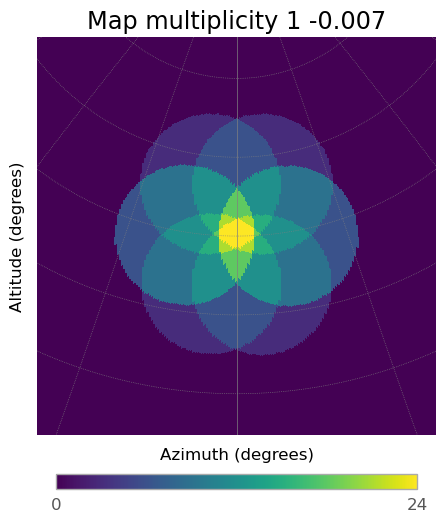

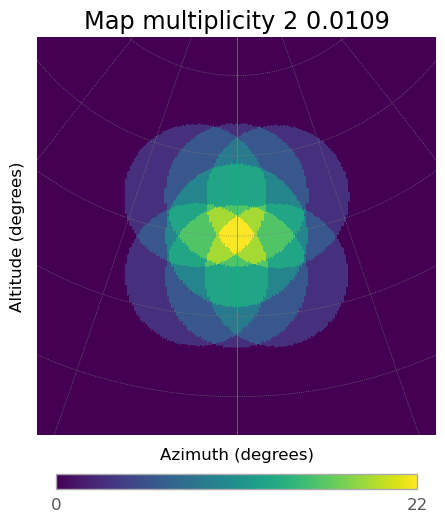

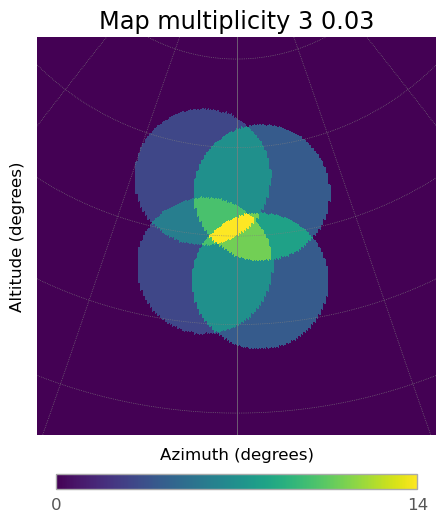

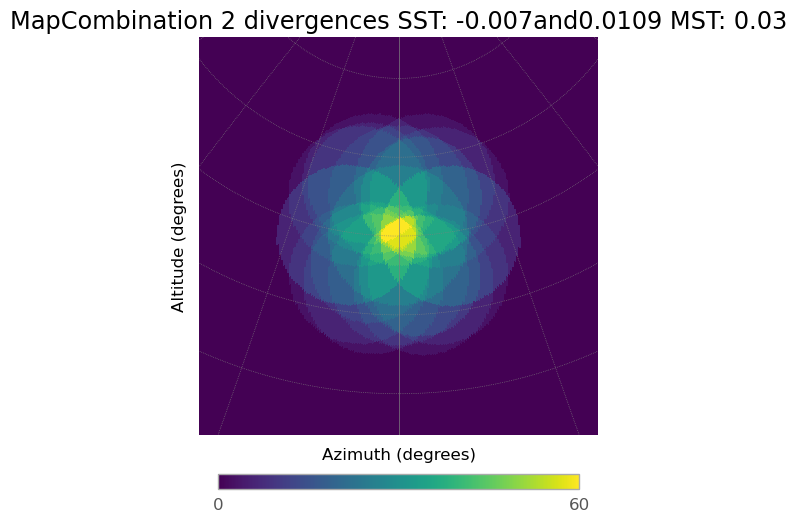

In [38]:
SST_config_conv.multiplicity_plot_3_config(array_2=SST_config_div,array_3=config_MST, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3= number_of_telescopes_subarray_1)




In [39]:
SST_config_conv.combiantion_of_FoV(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1)

6it [00:00,  6.41it/s]
7it [00:01,  6.42it/s]
4it [00:00,  6.23it/s]


(189.91641515543932, 18.488399392349123)

In [40]:
#From the table the ones to use for the array MST
#    0.0022
#    0.0043
#    0.008
#    0.01135
#    0.01453
# FOR THE SST the idea is to use 
#0.0022, 
#0.0043, 
#0.008, 
#0.01135, 
#0.013
#AND FOR THE CONVERGENCE TO USE: THIS WERE CALCULATED IN ORDER TO HAVE THE SAME HFOV AT THE CENTER FOR DIV AND CONV
#-0.0013434343434343427,
# -0.0026343434343434335,
# -0.005001010101010101,
# -0.007224242424242425,
# -0.0083]
#
#
#

In [41]:
div_MST=[0.0022,0.0043, 0.008, 0.01135, 0.01453]
divergence_list=[]
div_SST=np.linspace(0.001,0.014, 150)
for divergence in div_MST:
    for divergence_SST in div_SST:
        print(f" the div{divergence_SST}")
        config_MST.divergent_pointing(div=divergence, complete_array=combination_MST_SST, az=0, alt=70)
        hFoV_to_stop=config_MST.hFoV(m_cut=13, subarray_mult=number_of_telescopes_subarray_1 )[0]
        SST_config_div.divergent_pointing(div=divergence_SST, complete_array=combination_MST_SST,az=0, alt=70)
        print(f" the stop{round(hFoV_to_stop)}")
        hFoV_div=SST_config_div.hFoV(subarray_mult=number_of_telescopes_config_SST_second_half,m_cut=21)[0]
        print(f" the div h FoV {round(hFoV_div)}")
        if round(hFoV_div) == round(hFoV_to_stop):
            divergence_list.append(divergence_SST)
            print(f"stop, the {divergence_SST}")
            break 

 the div0.001
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


4it [00:00,  6.55it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
 the stop42


7it [00:01,  6.50it/s]


 the div h FoV 54
 the div0.001087248322147651
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


...

 the div h FoV 21
 the div0.006322147651006712
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


4it [00:00,  6.53it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
 the stop20


7it [00:01,  6.53it/s]


 the div h FoV 20
stop, the 0.006322147651006712


In [44]:
conv=np.linspace(-0.0083,-0.0012, 100)
convergence_list=[]
for divergence in divergence_list:
    for convergence in conv:
        SST_config_div.divergent_pointing(complete_array=combination_MST_SST, div=divergence, az=0, alt=70)
        hFoV_to_stop=SST_config_div.hFoV(subarray_mult=number_of_telescopes_config_SST_second_half,m_cut=21)[0]
        SST_config_conv.divergent_pointing(complete_array=combination_MST_SST, div=convergence, az=0, alt=70)
        hFoV_conv=SST_config_conv.hFoV(subarray_mult=number_of_telescopes_config_SST_first_half,m_cut=23)[0]
        if hFoV_conv > hFoV_to_stop:
            convergence_list.append(convergence)
            print(f"stop, the {convergence}")
            break 

The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


7it [00:01,  6.68it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


6it [00:00,  6.93it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


...

The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


7it [00:01,  6.20it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


6it [00:00,  6.19it/s]


stop, the -0.003925252525252525


In [45]:
divergence_list

[0.002657718120805369,
 0.0032684563758389267,
 0.004315436241610739,
 0.005362416107382551,
 0.006322147651006712]

In [46]:
convergence_list

[-0.0016303030303030297,
 -0.001988888888888888,
 -0.0026343434343434335,
 -0.00327979797979798,
 -0.003925252525252525]

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2217188394462803 rad
-0.0 rad
1.2109385635417547 rad
-0.030238296281990797 rad
1.2110830620647204 rad
0.030238296281990797 rad
1.2107847917574148 rad
-0.0 rad
1.232011007102679 rad
0.03225462205864594 rad
1.2317212952137329 rad
-0.03225462205864594 rad
1.2323594653520458 rad
-0.0 rad


6it [00:01,  5.77it/s]
7it [00:01,  6.20it/s]
4it [00:00,  6.09it/s]
6it [00:01,  5.88it/s]


10.212537349408727


7it [00:01,  6.13it/s]
4it [00:00,  6.22it/s]


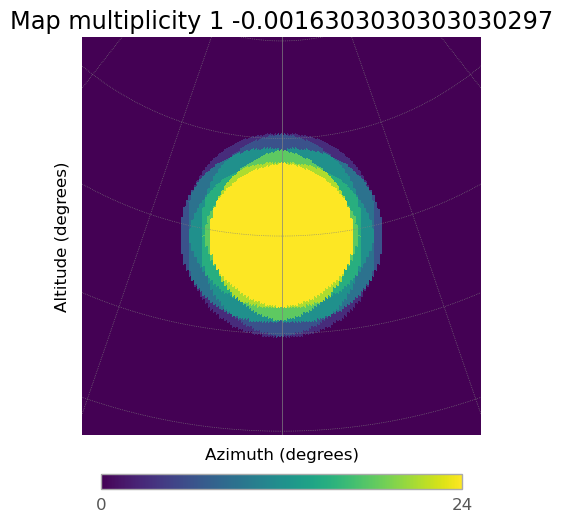

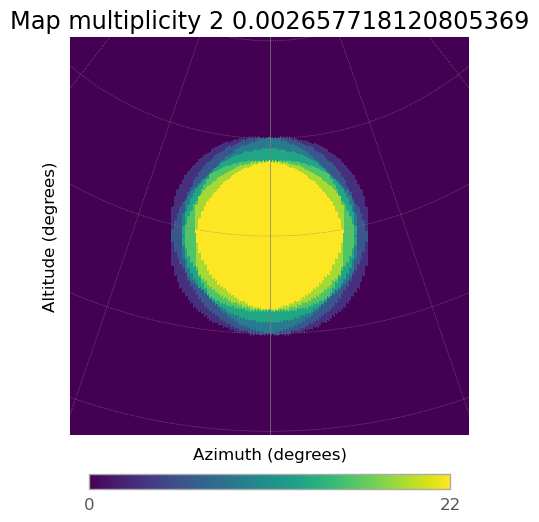

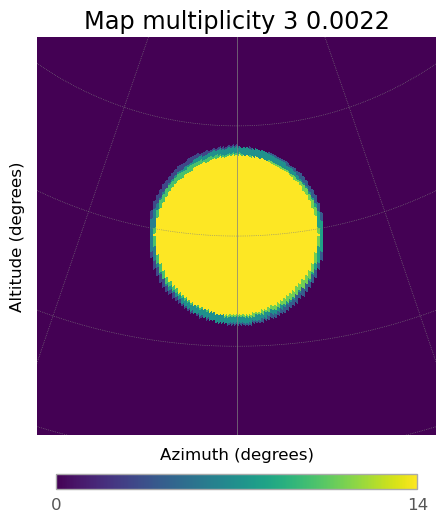

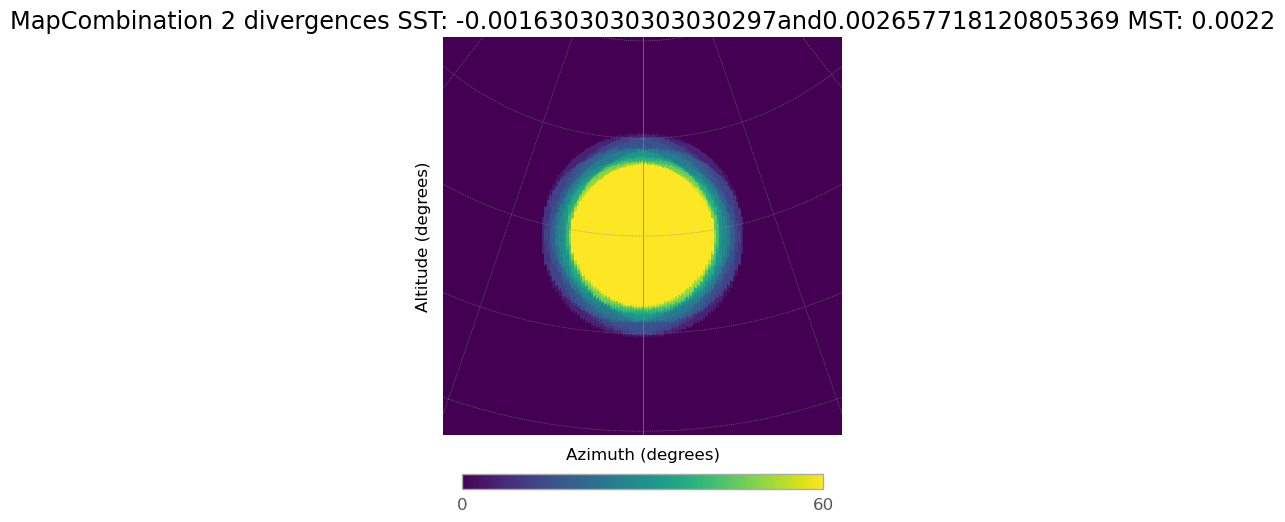

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2217161646649823 rad
-0.0 rad
1.2084285395669554 rad
-0.036912514295213625 rad
1.2086072632013176 rad
0.036912514295213625 rad
1.2082809175815372 rad
-0.0 rad
1.2343345600810356 rad
0.039961493124680676 rad
1.2339803102515179 rad
-0.039961493124680676 rad
1.2348133667522045 rad
-0.0 rad


6it [00:00,  6.22it/s]
7it [00:01,  6.16it/s]
4it [00:00,  6.02it/s]
6it [00:01,  5.81it/s]


10.381184608340572


7it [00:01,  6.24it/s]
4it [00:00,  6.23it/s]


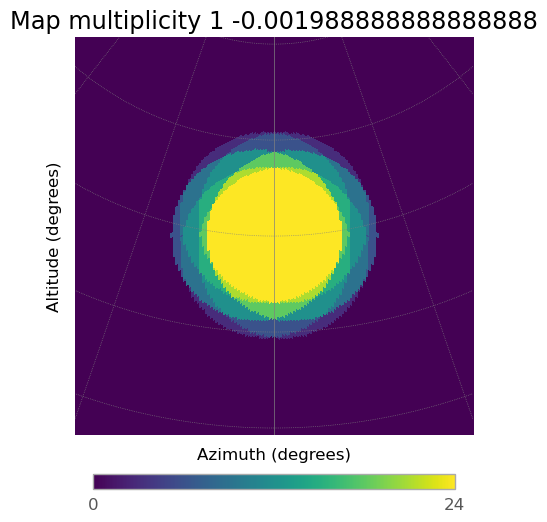

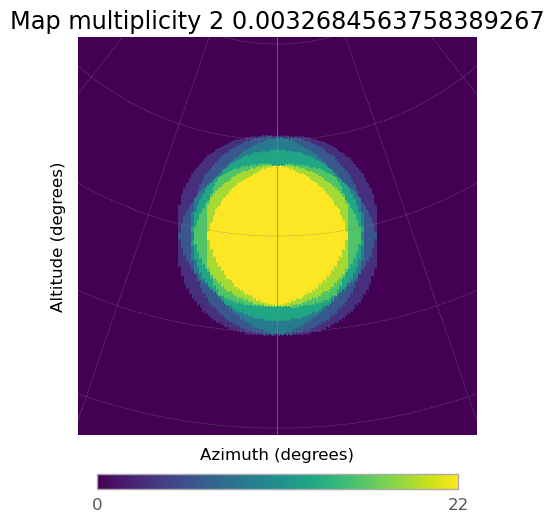

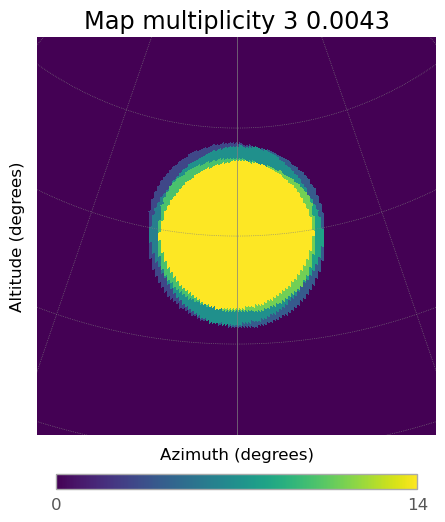

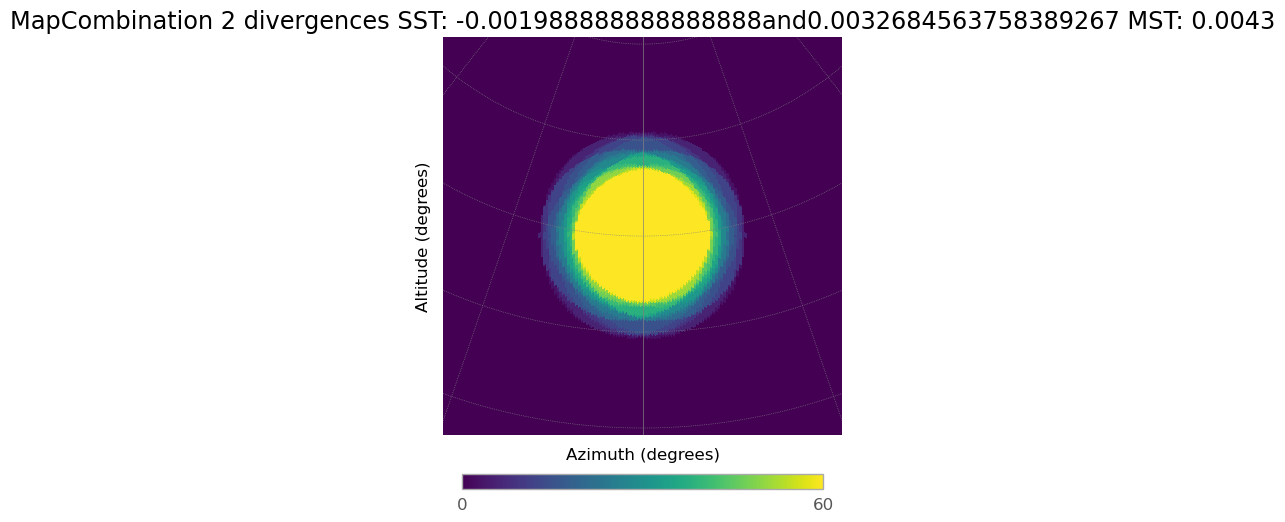

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2217115787580124 rad
-0.0 rad
1.2041018793937541 rad
-0.04812449236386484 rad
1.204340160447767 rad
0.04812449236386484 rad
1.2039985899177246 rad
-0.0 rad
1.2382812342907081 rad
0.05343820853982929 rad
1.237818099427101 rad
-0.05343820853982929 rad
1.239029864294229 rad
-0.0 rad


6it [00:01,  6.00it/s]
7it [00:01,  6.15it/s]
4it [00:00,  6.14it/s]
6it [00:01,  5.99it/s]


10.68117237697357


7it [00:01,  6.38it/s]
4it [00:00,  5.89it/s]


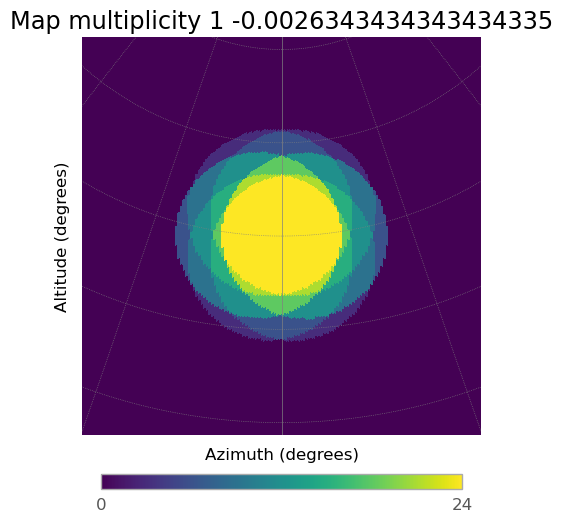

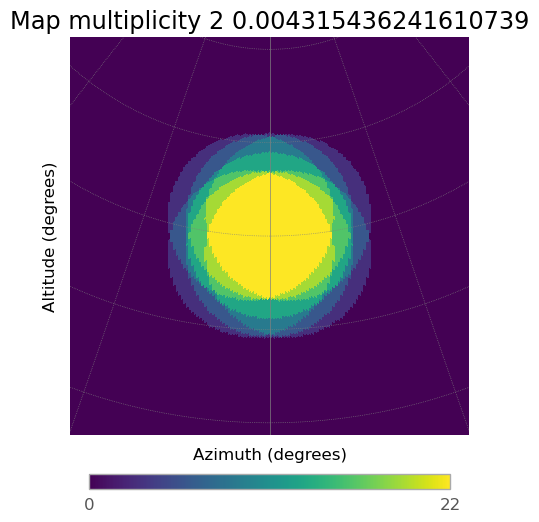

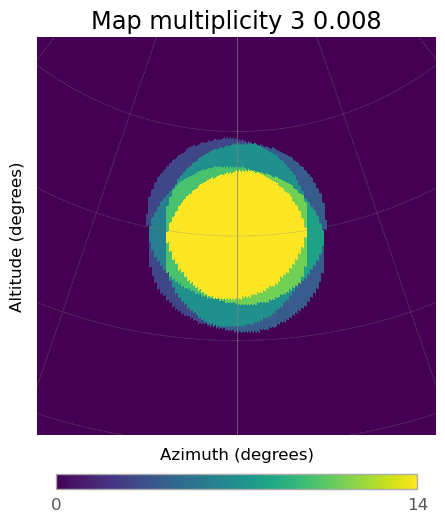

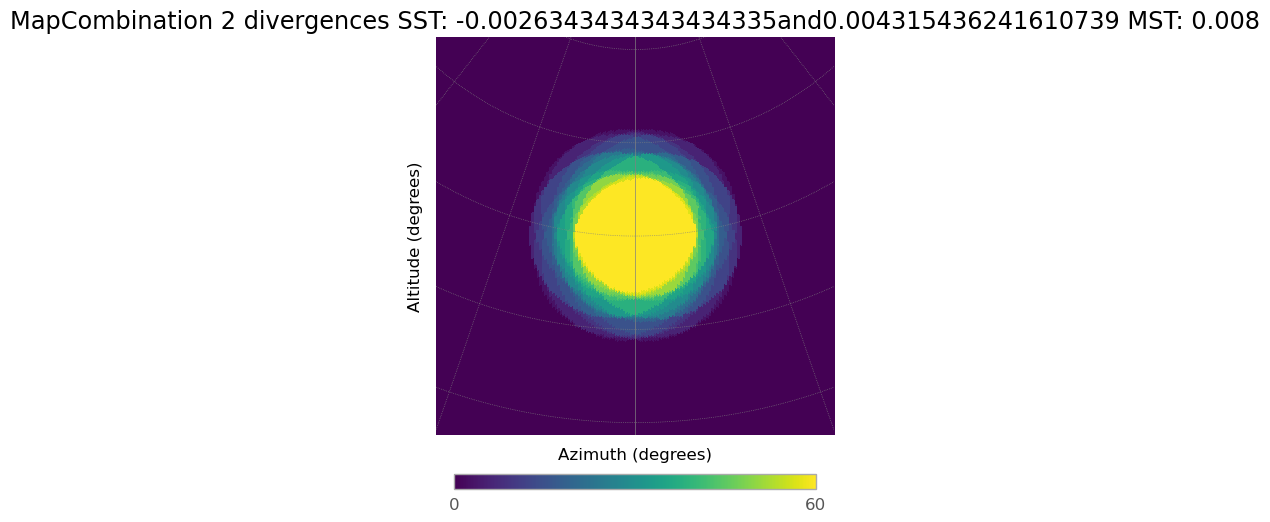

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.221706992120937 rad
-0.0 rad
1.1997469973866728 rad
-0.059053604770412806 rad
1.2000459524503915 rad
0.059053604770412806 rad
1.1997290035627002 rad
-0.0 rad
1.2421794626665716 rad
0.06725630834449484 rad
1.2416096346792478 rad
-0.06725630834449484 rad
1.2432586821436065 rad
-0.0 rad


6it [00:00,  6.02it/s]
7it [00:01,  6.13it/s]
4it [00:00,  6.25it/s]
6it [00:00,  6.04it/s]


10.975183953006017


7it [00:01,  6.32it/s]
4it [00:00,  6.13it/s]


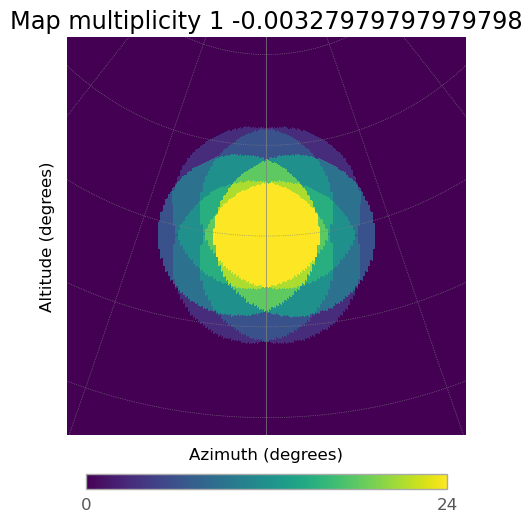

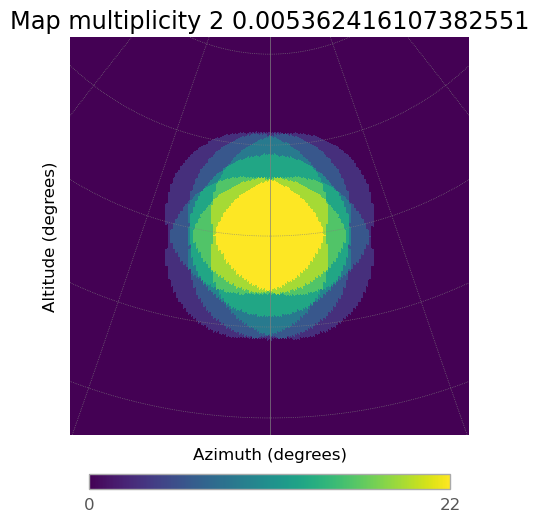

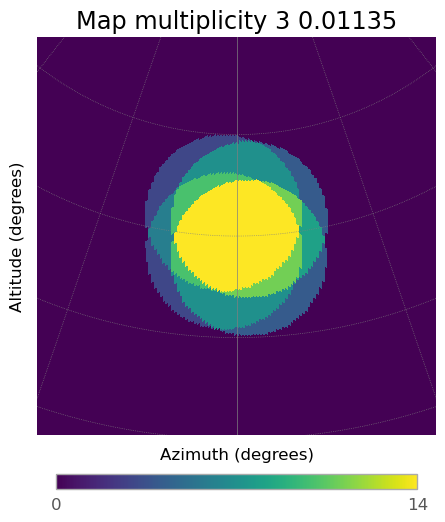

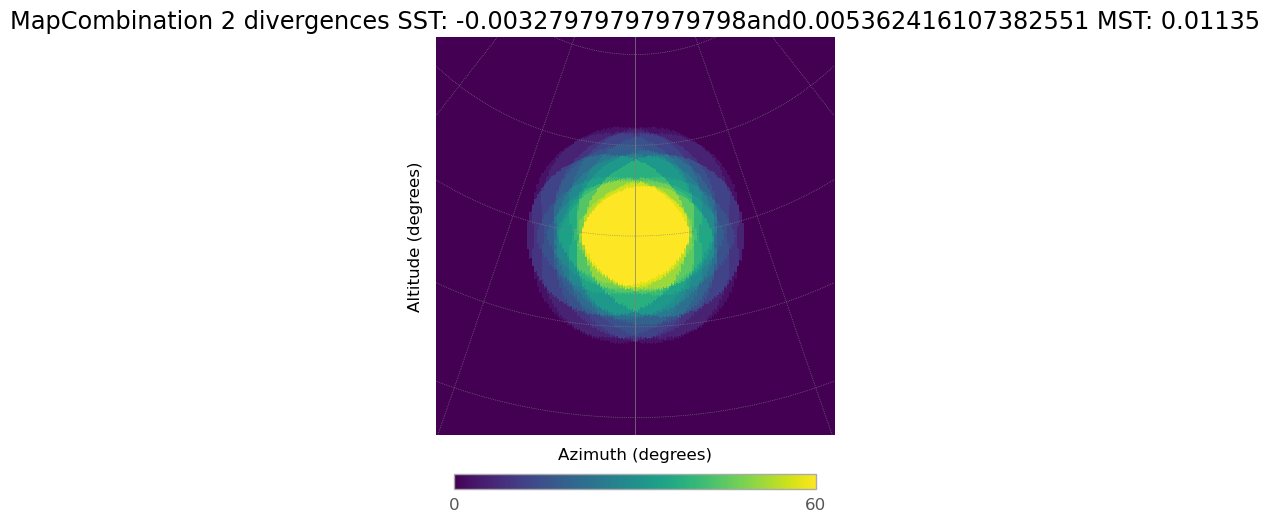

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.221702787049205 rad
-0.0 rad
1.1957319503152901 rad
-0.06883038158066719 rad
1.19608750072057 rad
0.06883038158066719 rad
1.195826480916881 rad
-0.0 rad
1.2457079698124311 rad
0.08022937898036672 rad
1.245042241730217 rad
-0.08022937898036672 rad
1.2471458499678052 rad
-0.0 rad


6it [00:00,  6.08it/s]
7it [00:01,  5.95it/s]
4it [00:00,  6.01it/s]
6it [00:01,  5.41it/s]


11.267391954913723


7it [00:01,  5.97it/s]
4it [00:00,  6.19it/s]


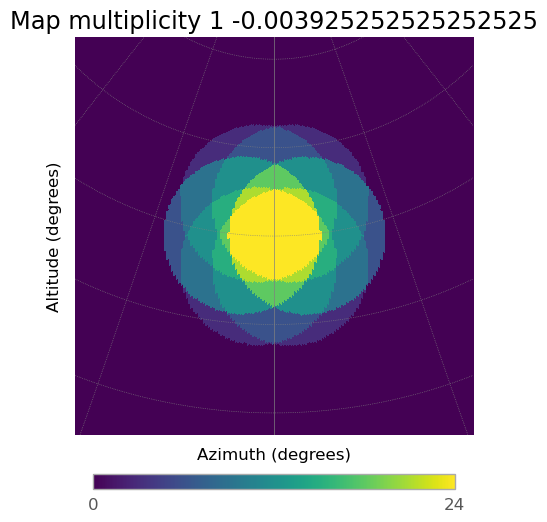

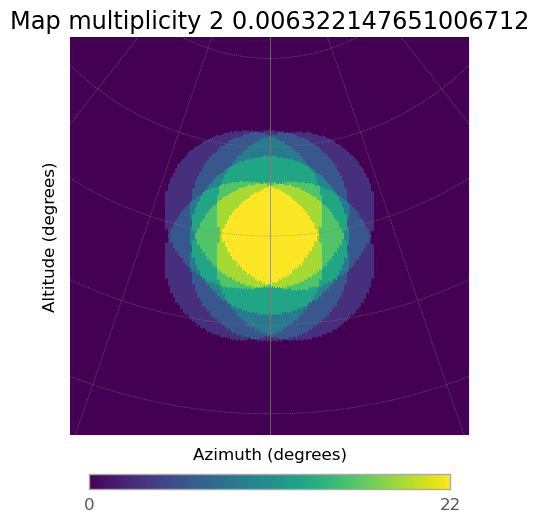

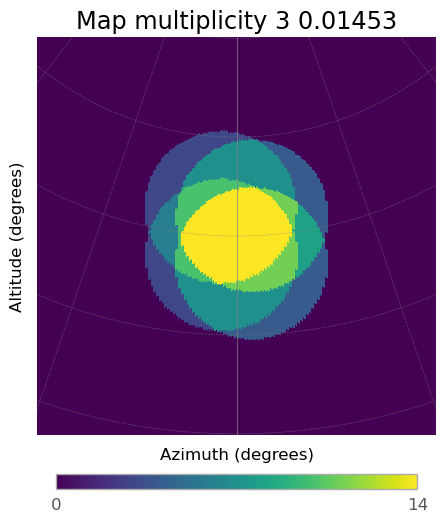

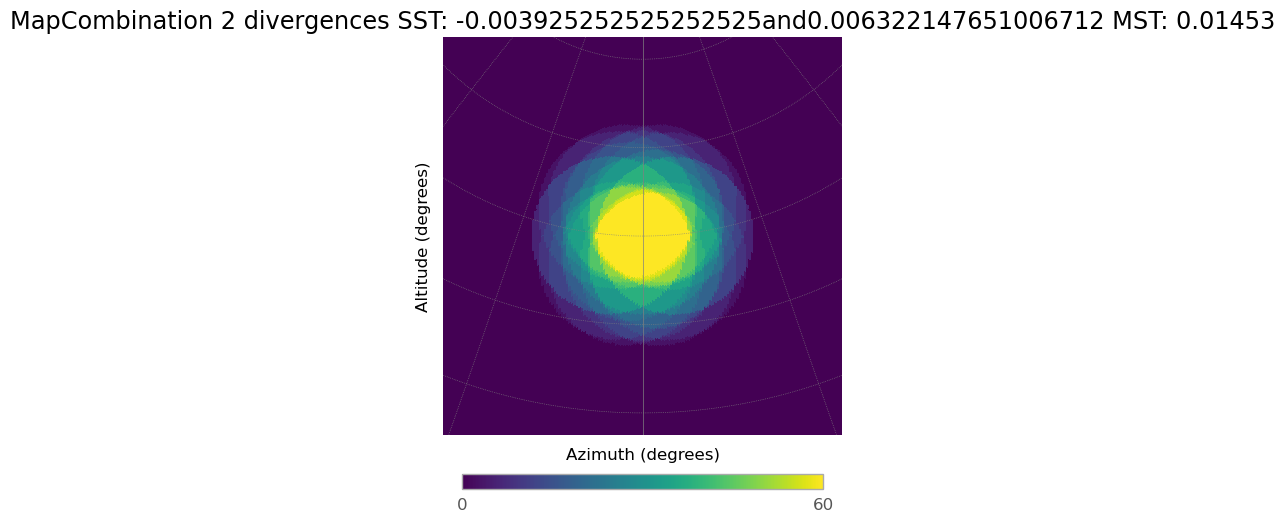

In [47]:

div_MST=[0.0022,0.0043, 0.008, 0.01135, 0.01453 ]
div_SST=divergence_list
conv_SST=convergence_list
for i in range(5):
    config_MST.divergent_pointing(div_MST[i], az=0,alt=70)
    SST_config_conv.divergent_pointing_2_div(tel_group_2=SST_config_div, complete_array=combination_MST_SST, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
    SST_config_conv.multiplicity_plot_3_config(array_2=SST_config_div,array_3=config_MST, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3= number_of_telescopes_subarray_1)





## UP TO 0.03

In [48]:
div_MST=[0.0022,0.0043, 0.008, 0.01135, 0.01453, 0.01753, 0.02053, 0.02353, 0.02653, 0.02953]

In [50]:
divergence_list=[]
div_SST=np.linspace(0.001,0.02222, 200)
for divergence in div_MST:
    for divergence_SST in div_SST:
        print(f" the div{divergence_SST}")
        config_MST.divergent_pointing(div=divergence, complete_array=combination_MST_SST, az=0, alt=70)
        hFoV_to_stop=config_MST.hFoV(m_cut=13, subarray_mult=number_of_telescopes_subarray_1 )[0]
        SST_config_div.divergent_pointing(complete_array=combination_MST_SST,div=divergence_SST, az=0, alt=70)
        print(f" the stop{round(hFoV_to_stop)}")
        hFoV_div=SST_config_div.hFoV(subarray_mult=number_of_telescopes_config_SST_second_half,m_cut=21)[0]
        print(f" the div h FoV {round(hFoV_div)}")
        if round(hFoV_div) == round(hFoV_to_stop):
            divergence_SST=round(divergence_SST, 6)
            divergence_list.append(divergence_SST)
            print(f"stop, the {divergence_SST}")
            break 

 the div0.001
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


4it [00:00,  4.41it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
 the stop42


7it [00:01,  6.45it/s]


 the div h FoV 54
 the div0.0011066331658291456
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


...

 the div h FoV 4
 the div0.010916884422110553
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


4it [00:00,  4.56it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
 the stop3


7it [00:01,  4.33it/s]

 the div h FoV 3
stop, the 0.010917


In [51]:
conv=np.linspace(-0.0083,-0.0012, 100)
convergence_list=[]
for divergence in divergence_list:
    for convergence in conv:
        SST_config_div.divergent_pointing(complete_array=combination_MST_SST,div=divergence, az=0, alt=70)
        hFoV_to_stop=SST_config_div.hFoV(subarray_mult=number_of_telescopes_config_SST_second_half,m_cut=21)[0]
        SST_config_conv.divergent_pointing(complete_array=combination_MST_SST,div=convergence, az=0, alt=70)
        hFoV_conv=SST_config_conv.hFoV(subarray_mult=number_of_telescopes_config_SST_first_half,m_cut=23)[0]
        if hFoV_conv > hFoV_to_stop:
            convergence=round(convergence,5)
            convergence_list.append(convergence)
            print(f"stop, the {convergence}")
            break 

The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


7it [00:02,  2.45it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


6it [00:01,  5.76it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


...

The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


7it [00:02,  3.43it/s]


The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


6it [00:01,  5.06it/s]


stop, the -0.00694


In [52]:
convergence_list

[-0.00163,
 -0.00199,
 -0.00263,
 -0.00328,
 -0.00393,
 -0.00464,
 -0.00514,
 -0.00572,
 -0.00636,
 -0.00694]

In [53]:
divergence_list

[0.002706,
 0.003239,
 0.004306,
 0.005372,
 0.006332,
 0.007398,
 0.008251,
 0.009104,
 0.010064,
 0.010917]

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.221718628000376 rad
-0.0 rad
1.2107405190700038 rad
-0.030769570454969013 rad
1.2108877093864527 rad
0.030769570454969013 rad
1.2105866917721522 rad
-0.0 rad
1.2321952511351593 rad
0.032859792892439746 rad
1.231900409665488 rad
-0.032859792892439746 rad
1.2325533043954682 rad
-0.0 rad


6it [00:01,  4.68it/s]
7it [00:01,  5.11it/s]
4it [00:00,  5.56it/s]
6it [00:01,  5.14it/s]


10.212537349408727


7it [00:01,  4.69it/s]
4it [00:00,  5.59it/s]


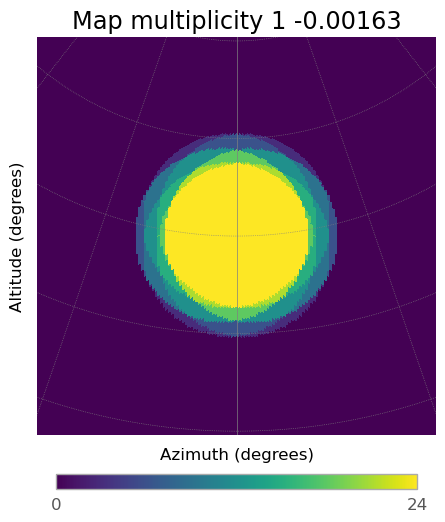

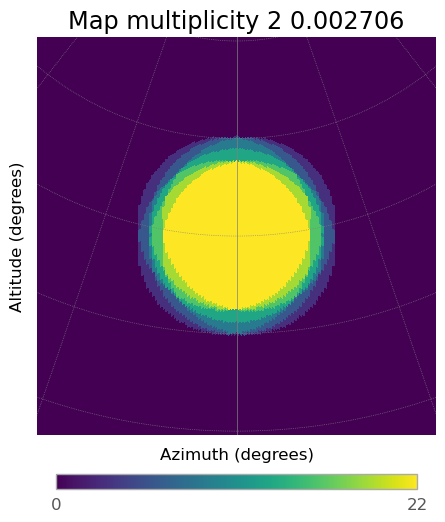

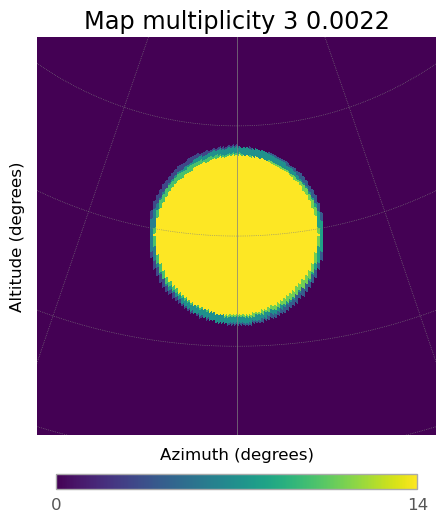

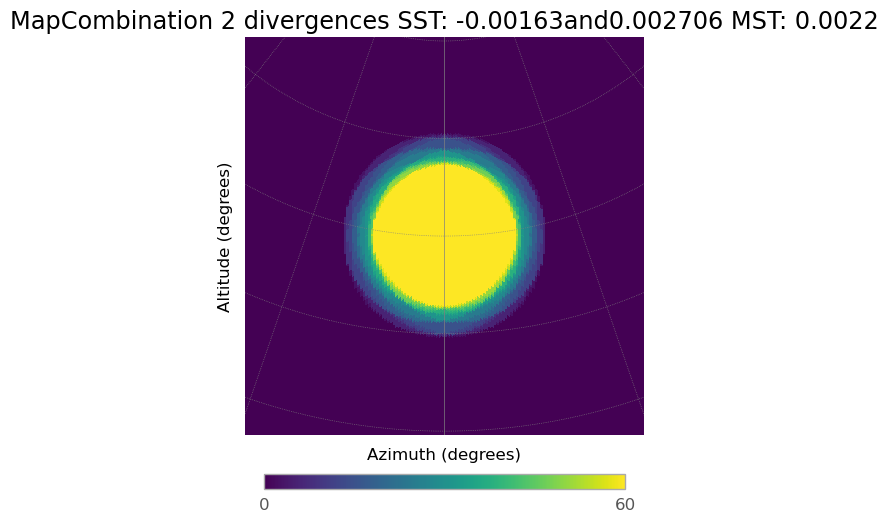

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2217162936773007 rad
-0.0 rad
1.2085498400581682 rad
-0.03659289831057362 rad
1.208726904245121 rad
0.03659289831057362 rad
1.2084015826616608 rad
-0.0 rad
1.234222847082614 rad
0.03958719212843469 rad
1.2338716926313198 rad
-0.03958719212843469 rad
1.2346949162092382 rad
-0.0 rad


6it [00:01,  5.73it/s]
7it [00:01,  6.20it/s]
4it [00:00,  5.93it/s]
6it [00:01,  5.88it/s]


10.381572455442473


7it [00:01,  5.49it/s]
4it [00:00,  5.95it/s]


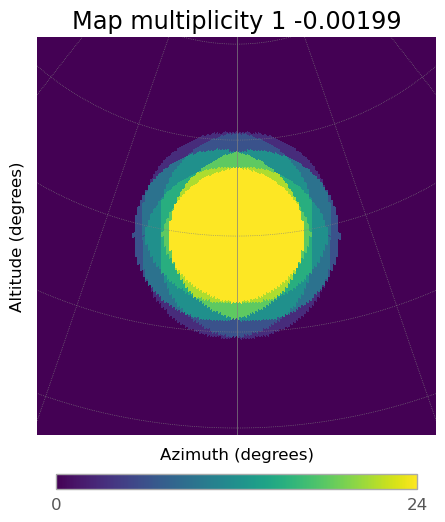

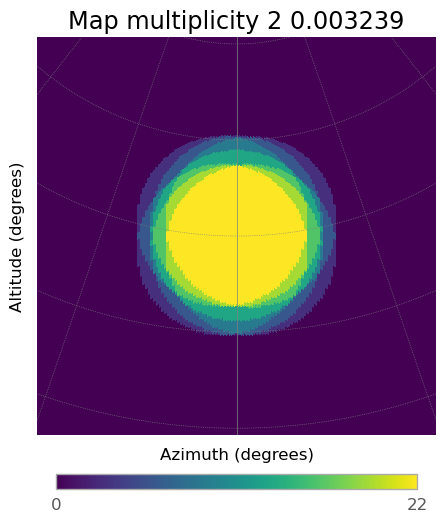

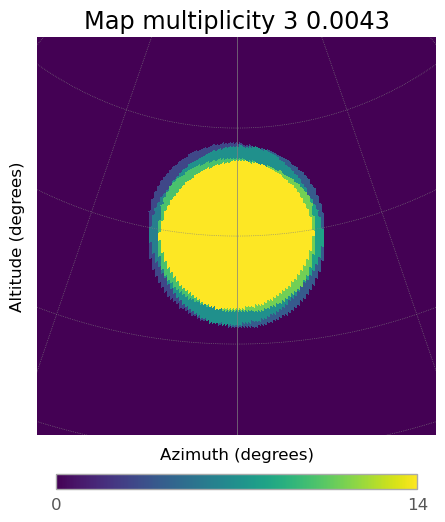

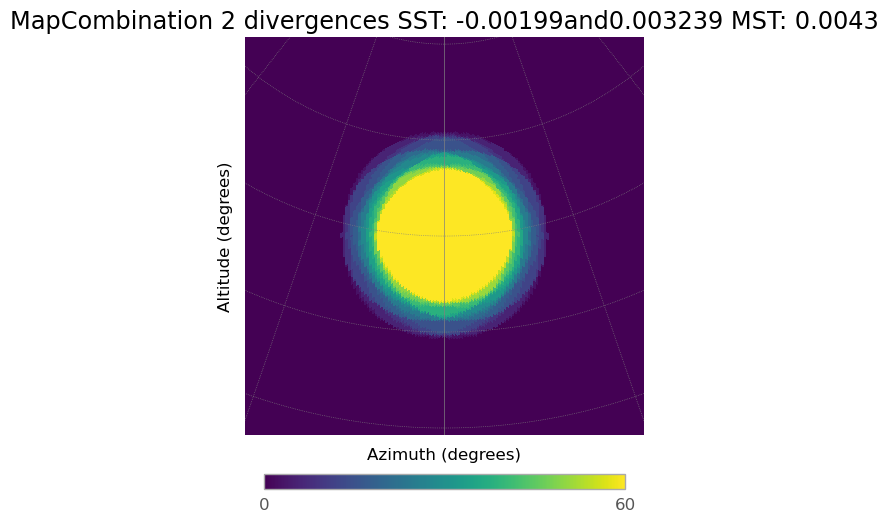

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2217116200932068 rad
-0.0 rad
1.2041410039194174 rad
-0.0480247163022836 rad
1.2043787432017097 rad
0.0480247163022836 rad
1.2040371289964713 rad
-0.0 rad
1.2382458759717871 rad
0.05331523244377358 rad
1.237783712642596 rad
-0.05331523244377358 rad
1.2389918066143946 rad
-0.0 rad


6it [00:01,  5.89it/s]
7it [00:01,  6.28it/s]
4it [00:00,  6.12it/s]
6it [00:01,  5.78it/s]


10.679702664783157


7it [00:01,  6.22it/s]
4it [00:00,  6.07it/s]


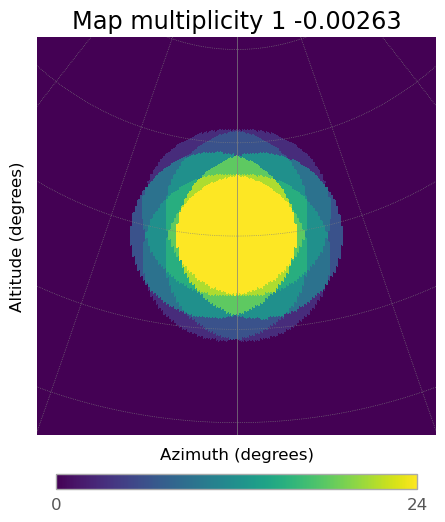

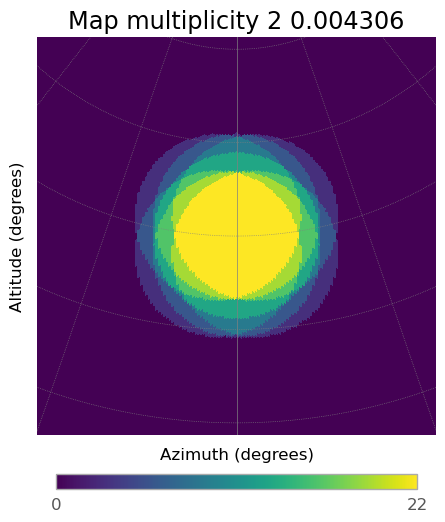

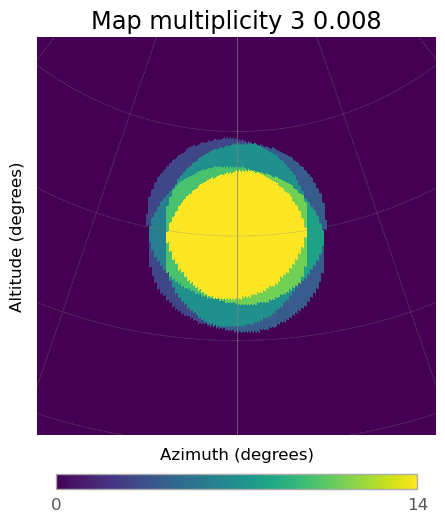

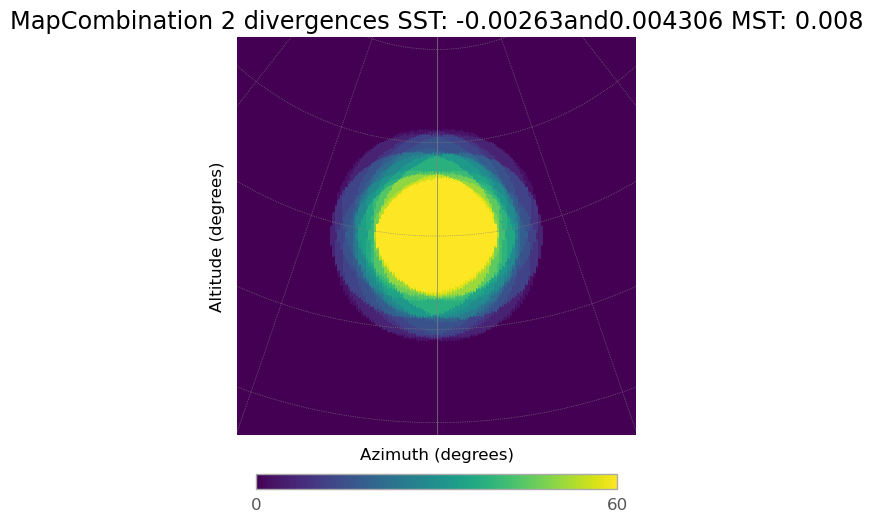

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.221706950132147 rad
-0.0 rad
1.1997070093994524 rad
-0.05915236682246129 rad
1.2000065250097576 rad
0.05915236682246129 rad
1.1996899795381033 rad
-0.0 rad
1.2422149143782817 rad
0.06738439783886906 rad
1.2416441197802888 rad
-0.06738439783886906 rad
1.2432974487391357 rad
-0.0 rad


6it [00:01,  5.89it/s]
7it [00:01,  5.88it/s]
4it [00:00,  6.31it/s]
6it [00:01,  5.97it/s]


10.975533246196212


7it [00:01,  6.24it/s]
4it [00:00,  6.40it/s]


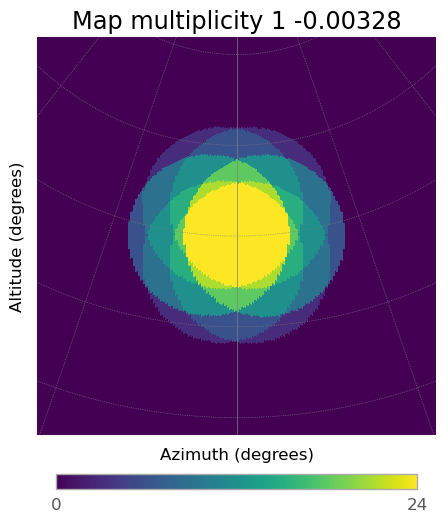

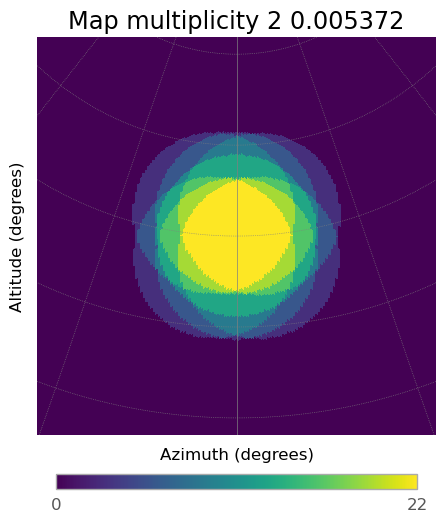

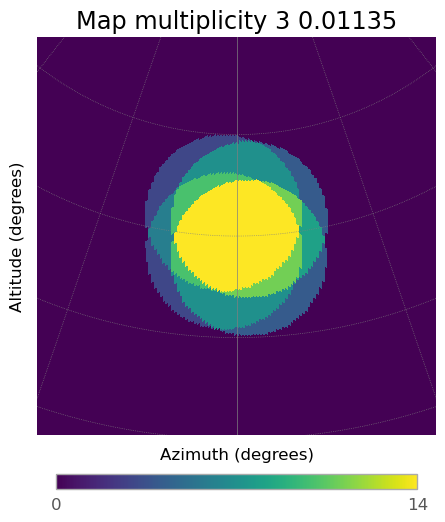

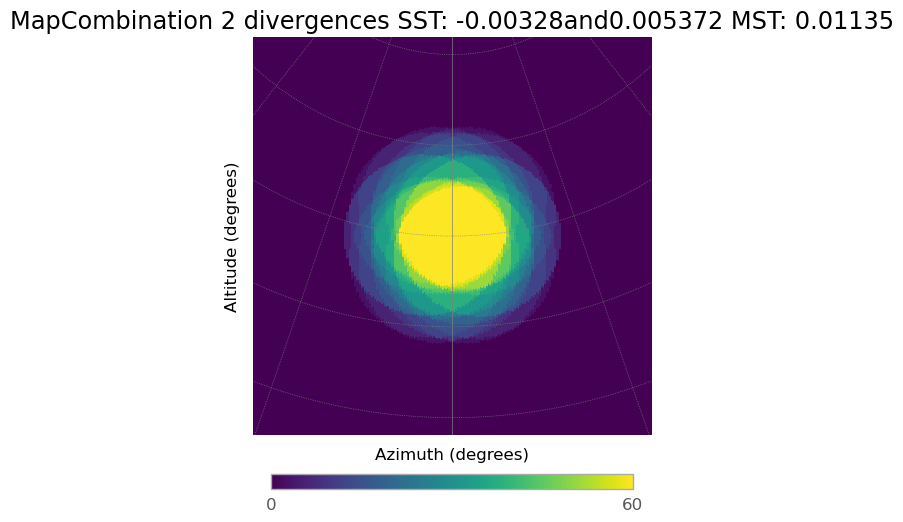

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2217027438777672 rad
-0.0 rad
1.1956906239481058 rad
-0.068929571466155 rad
1.1960467601806093 rad
0.068929571466155 rad
1.19578647476224 rad
-0.0 rad
1.2457439622322097 rad
0.0803640984914592 rad
1.245077259012212 rad
-0.0803640984914592 rad
1.2471858076891629 rad
-0.0 rad


6it [00:01,  5.42it/s]
7it [00:01,  5.49it/s]
4it [00:00,  5.32it/s]
6it [00:01,  5.75it/s]


11.270388397359302


7it [00:01,  5.68it/s]
4it [00:00,  5.51it/s]


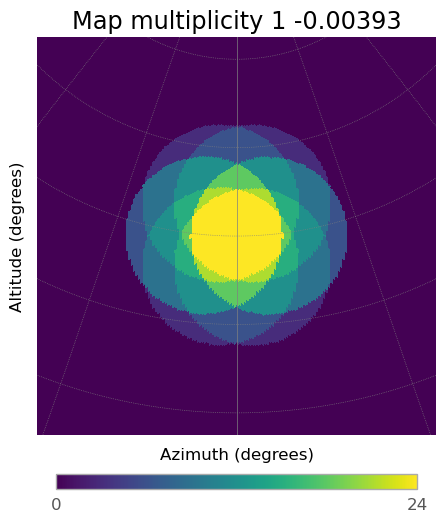

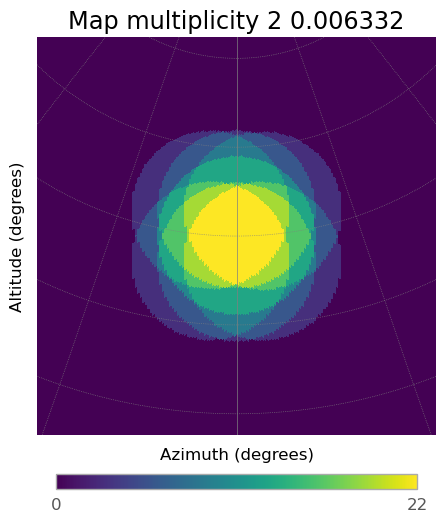

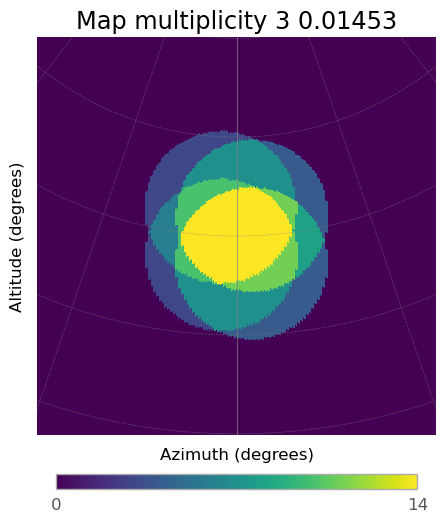

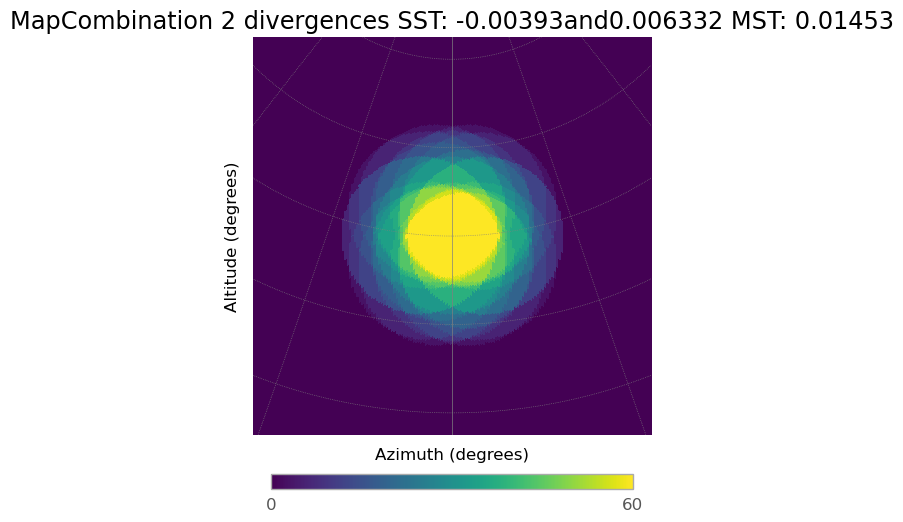

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2216980724340825 rad
-0.0 rad
1.1912067761995824 rad
-0.0795231657296136 rad
1.1916268758762074 rad
0.0795231657296136 rad
1.1914646702204557 rad
-0.0 rad
1.2496096455606895 rad
0.0951280028968922 rad
1.2488385453167365 rad
-0.0951280028968922 rad
1.2515154793734338 rad
-0.0 rad


6it [00:01,  5.96it/s]
7it [00:01,  5.41it/s]
4it [00:00,  5.59it/s]
6it [00:01,  5.39it/s]


11.593269543156513


7it [00:01,  5.26it/s]
4it [00:00,  5.94it/s]


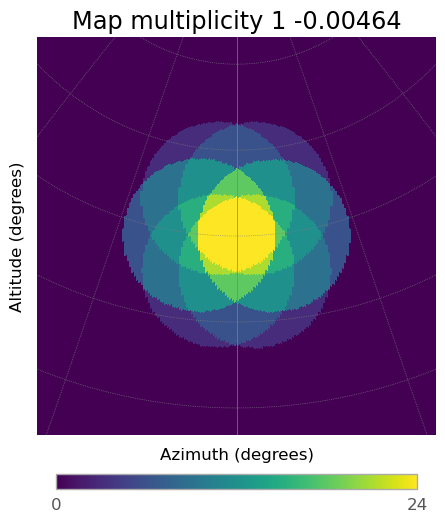

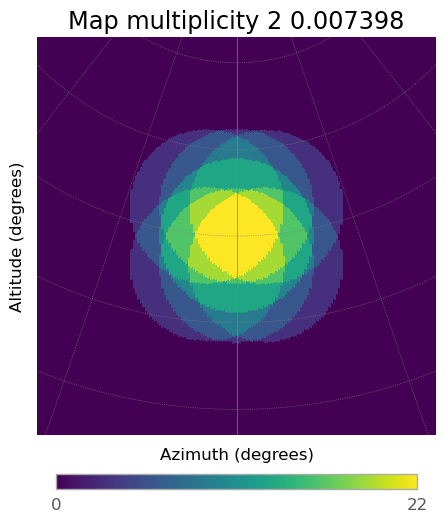

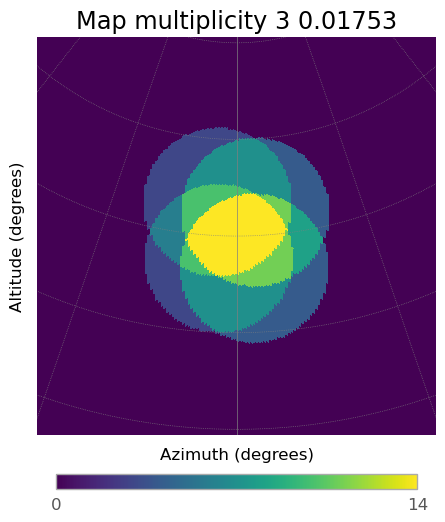

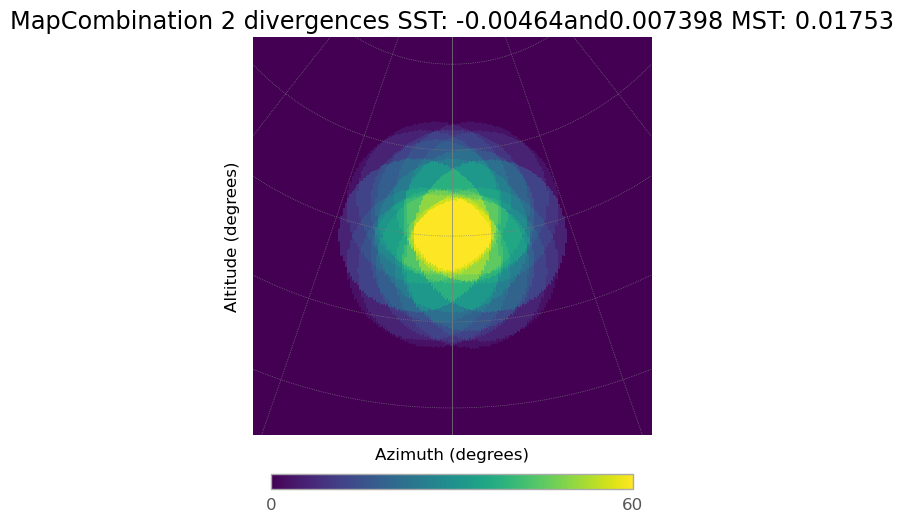

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2216943338247592 rad
-0.0 rad
1.1876019563461733 rad
-0.0878058907242029 rad
1.1880740611296465 rad
0.0878058907242029 rad
1.1880161053318192 rad
-0.0 rad
1.2526607602824587 rad
0.10721297849275463 rad
1.2518076904930986 rad
-0.10721297849275463 rad
1.2549890435499726 rad
-0.0 rad


6it [00:01,  5.74it/s]
7it [00:01,  5.57it/s]
4it [00:00,  5.81it/s]
6it [00:01,  5.07it/s]


11.813707551455323


7it [00:01,  5.38it/s]
4it [00:00,  4.56it/s]


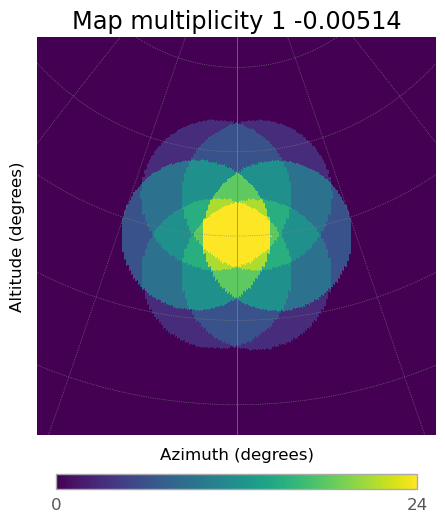

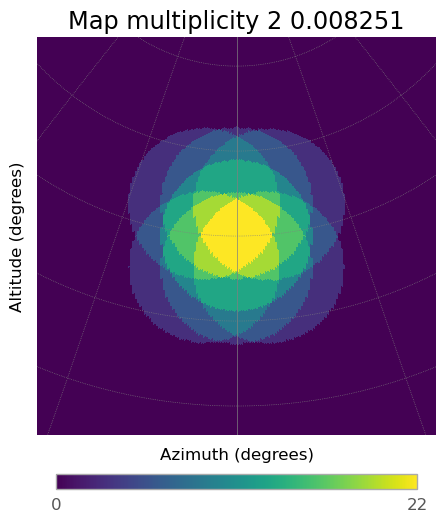

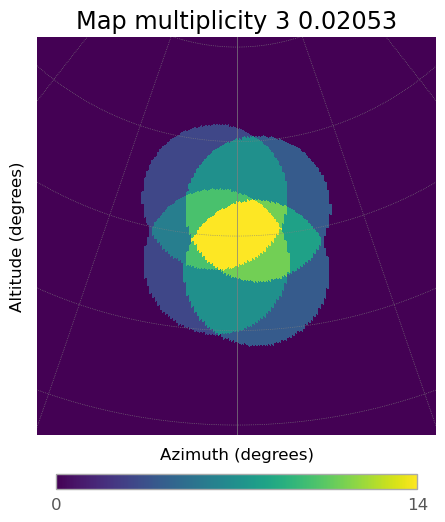

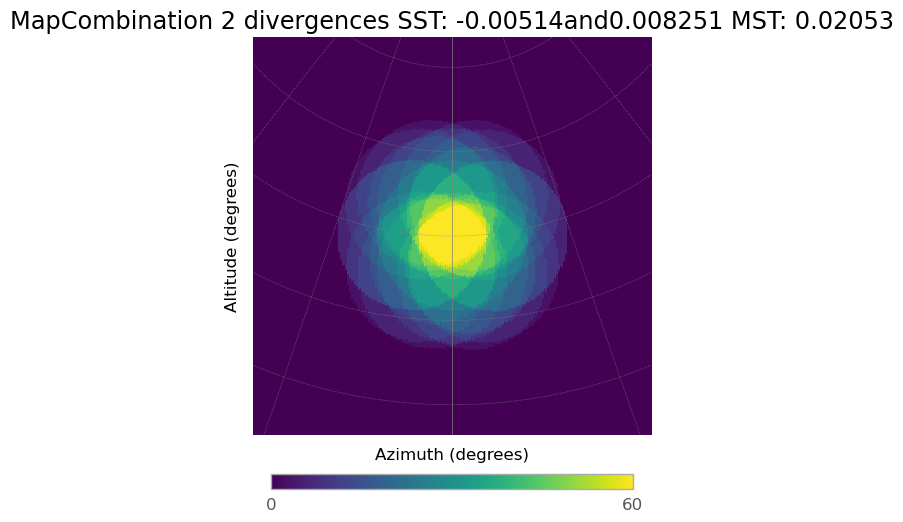

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2216905946926957 rad
-0.0 rad
1.18398316986227 rad
-0.09592049998757558 rad
1.1845080063035185 rad
0.09592049998757558 rad
1.1845762001359375 rad
-0.0 rad
1.2556726715610482 rad
0.11954311444331239 rad
1.2547390017869353 rad
-0.11954311444331239 rad
1.2584705689779159 rad
-0.0 rad


6it [00:01,  5.76it/s]
7it [00:01,  6.12it/s]
4it [00:00,  6.21it/s]
6it [00:01,  5.94it/s]


12.07105472591468


7it [00:01,  6.07it/s]
4it [00:00,  6.26it/s]


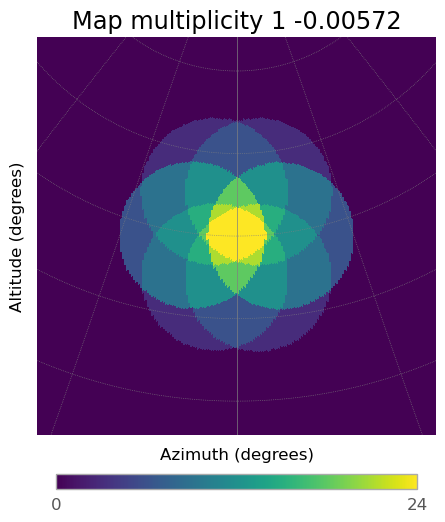

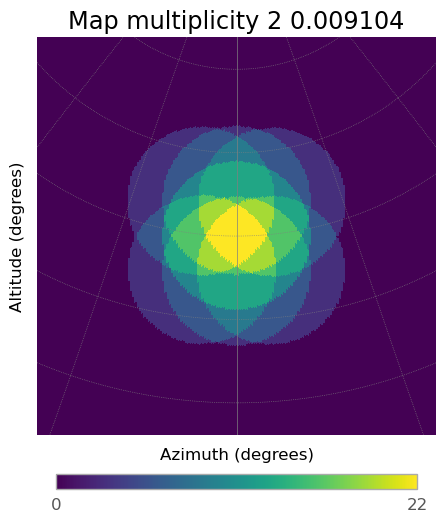

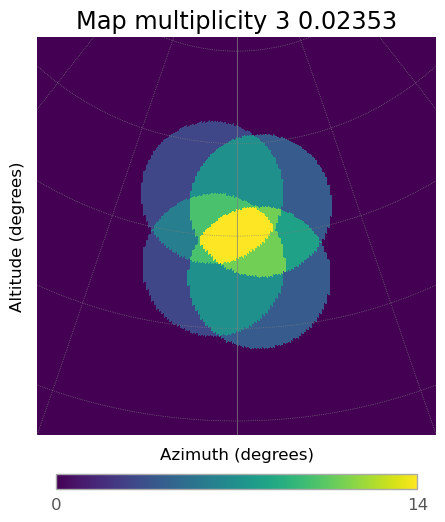

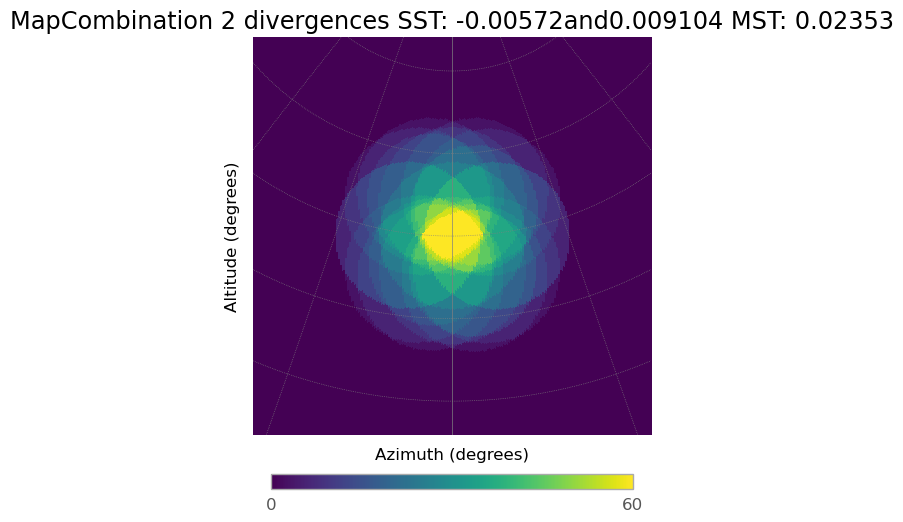

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2216863858897864 rad
-0.0 rad
1.1798949149455222 rad
-0.10485697198496681 rad
1.180479960740879 rad
0.10485697198496681 rad
1.1807152028509154 rad
-0.0 rad
1.2590134723644335 rad
0.1337177599470416 rad
1.2579906994192287 rad
-0.1337177599470416 rad
1.2623982756049443 rad
-0.0 rad


6it [00:01,  5.44it/s]
7it [00:01,  6.02it/s]
4it [00:00,  5.75it/s]
6it [00:01,  5.62it/s]


12.35747076318888


7it [00:01,  6.14it/s]
4it [00:00,  6.07it/s]


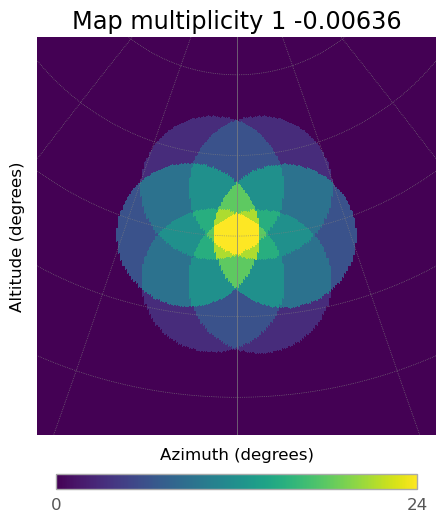

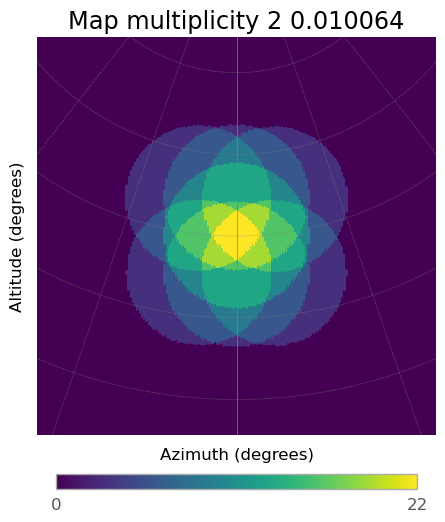

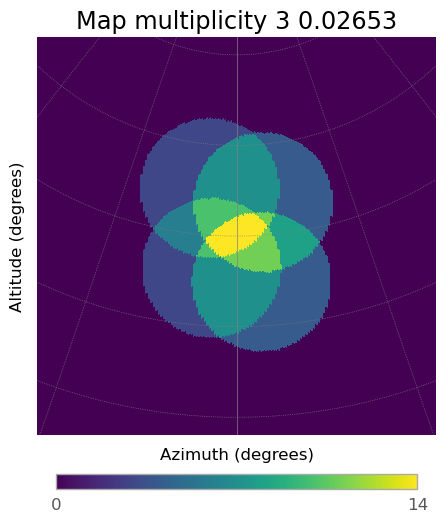

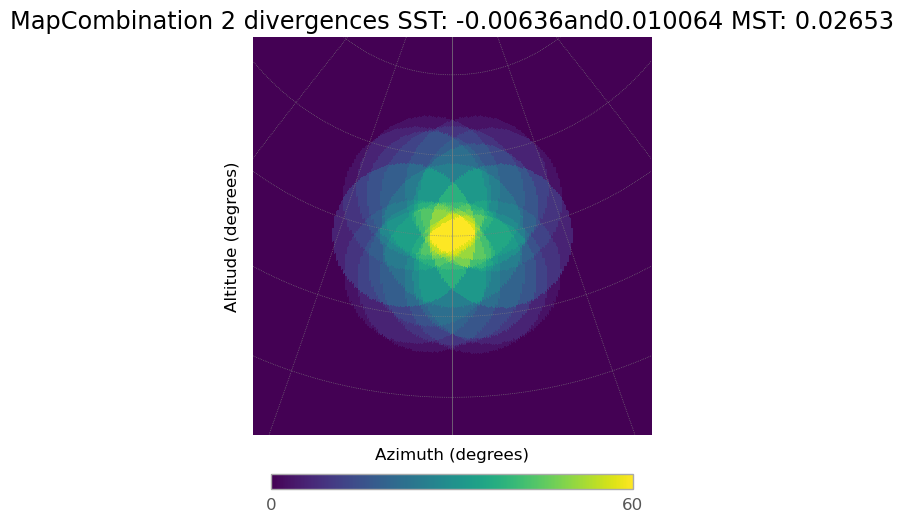

The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2216826456191796 rad
-0.0 rad
1.1762495421592145 rad
-0.11262760544242559 rad
1.1768888475105126 rad
0.11262760544242559 rad
1.177293838398536 rad
-0.0 rad
1.261936592766106 rad
0.14658105300572422 rad
1.2608360460477521 rad
-0.14658105300572422 rad
1.2658965560488145 rad
-0.0 rad


6it [00:00,  6.02it/s]
7it [00:01,  5.83it/s]
4it [00:00,  5.81it/s]
6it [00:01,  5.39it/s]


12.615353396701982


7it [00:01,  5.90it/s]
4it [00:00,  5.87it/s]


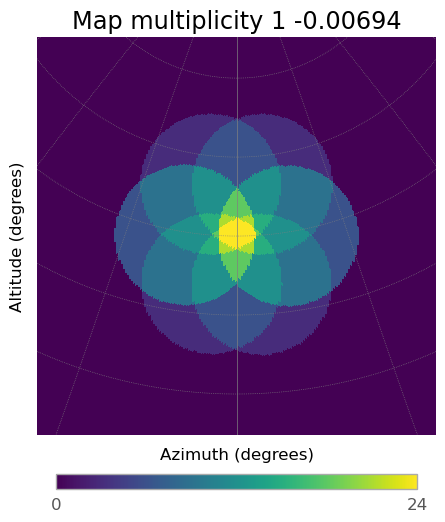

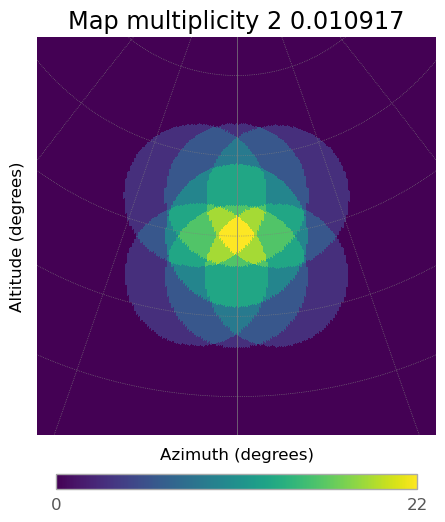

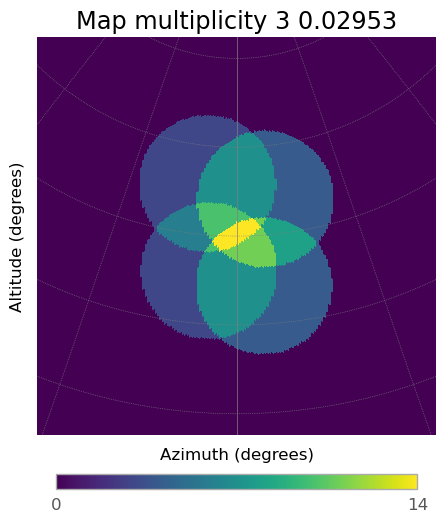

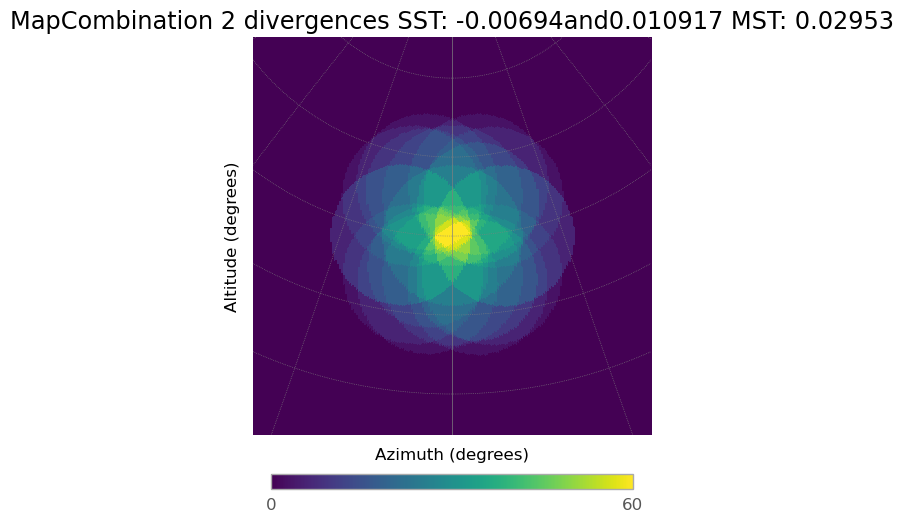

In [54]:
div_SST=divergence_list
conv_SST=convergence_list
for i in range(10):
    config_MST.divergent_pointing(div_MST[i], az=0,alt=70)
    SST_config_conv.divergent_pointing_2_div(tel_group_2=SST_config_div, complete_array=combination_MST_SST, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
    SST_config_conv.multiplicity_plot_3_config(array_2=SST_config_div,array_3=config_MST, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3= number_of_telescopes_subarray_1)



In [55]:
SST_config_conv.combiantion_of_FoV(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1)

6it [00:01,  5.63it/s]
7it [00:01,  6.18it/s]
4it [00:00,  5.91it/s]


(189.37874266397594, 18.544006647739078)

In [56]:
div_SST=divergence_list
conv_SST=convergence_list
m_ave_combine=[]
hFoV_combine=[]
for i in range(10):
    config_MST.divergent_pointing(div_MST[i], az=0,alt=70)
    SST_config_conv.divergent_pointing_2_div(tel_group_2=SST_config_div, complete_array=combination_MST_SST, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
    hFoV_combine.append(SST_config_conv.combiantion_of_FoV(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1)[0])
    m_ave_combine.append(SST_config_conv.combiantion_of_FoV(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1)[1])





The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.221718628000376 rad
-0.0 rad
1.2107405190700038 rad
-0.030769570454969013 rad
1.2108877093864527 rad
0.030769570454969013 rad
1.2105866917721522 rad
-0.0 rad
1.2321952511351593 rad
0.032859792892439746 rad
1.231900409665488 rad
-0.032859792892439746 rad
1.2325533043954682 rad
-0.0 rad


6it [00:01,  5.68it/s]
7it [00:01,  5.95it/s]
4it [00:00,  5.74it/s]
6it [00:01,  5.74it/s]
7it [00:01,  4.55it/s]
4it [00:00,  5.56it/s]


The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2217162936773007 rad
-0.0 rad
1.2085498400581682 rad
-0.03659289831057362 rad
1.208726904245121 rad
0.03659289831057362 rad
1.2084015826616608 rad
-0.0 rad
1.234222847082614 rad
0.03958719212843469 rad
1.2338716926313198 rad
-0.03958719212843469 rad
1.2346949162092382 rad
-0.0 rad


6it [00:01,  5.63it/s]
7it [00:01,  5.91it/s]
4it [00:00,  5.75it/s]
6it [00:01,  5.89it/s]
7it [00:01,  6.01it/s]
4it [00:00,  6.08it/s]


The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2217116200932068 rad
-0.0 rad
1.2041410039194174 rad
-0.0480247163022836 rad
1.2043787432017097 rad
0.0480247163022836 rad
1.2040371289964713 rad
-0.0 rad
1.2382458759717871 rad
0.05331523244377358 rad
1.237783712642596 rad
-0.05331523244377358 rad
1.2389918066143946 rad
-0.0 rad


...

6it [00:00,  6.02it/s]
7it [00:01,  6.07it/s]
4it [00:00,  5.90it/s]
6it [00:01,  5.71it/s]
7it [00:01,  6.02it/s]
4it [00:00,  5.90it/s]


The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2216863858897864 rad
-0.0 rad
1.1798949149455222 rad
-0.10485697198496681 rad
1.180479960740879 rad
0.10485697198496681 rad
1.1807152028509154 rad
-0.0 rad
1.2590134723644335 rad
0.1337177599470416 rad
1.2579906994192287 rad
-0.1337177599470416 rad
1.2623982756049443 rad
-0.0 rad


6it [00:00,  6.08it/s]
7it [00:01,  6.32it/s]
4it [00:00,  6.17it/s]
6it [00:01,  5.86it/s]
7it [00:01,  6.11it/s]
4it [00:00,  6.20it/s]


The barycenter -26.08250000000001
The barycenter -13.394999999999996
The barycenter 28.009999999999998
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.2216826456191796 rad
-0.0 rad
1.1762495421592145 rad
-0.11262760544242559 rad
1.1768888475105126 rad
0.11262760544242559 rad
1.177293838398536 rad
-0.0 rad
1.261936592766106 rad
0.14658105300572422 rad
1.2608360460477521 rad
-0.14658105300572422 rad
1.2658965560488145 rad
-0.0 rad


6it [00:00,  6.16it/s]
7it [00:01,  6.08it/s]
4it [00:00,  6.04it/s]
6it [00:00,  6.07it/s]
7it [00:01,  6.27it/s]
4it [00:00,  6.17it/s]


In [57]:
hFoV_combine

[86.77509453691079,
 92.57146627415041,
 103.63965122037267,
 115.38976225332901,
 127.03496158063395,
 140.68659727852184,
 151.0072863219779,
 162.82296717096636,
 176.48771683206067,
 189.37874266397594]

In [58]:
m_ave_combine

[40.46728124527731,
 37.94744298059215,
 33.88928255093003,
 30.441186498465736,
 27.646330133168163,
 24.961409395973153,
 23.25115067303517,
 21.563063788659793,
 19.89218308812602,
 18.544006647739078]

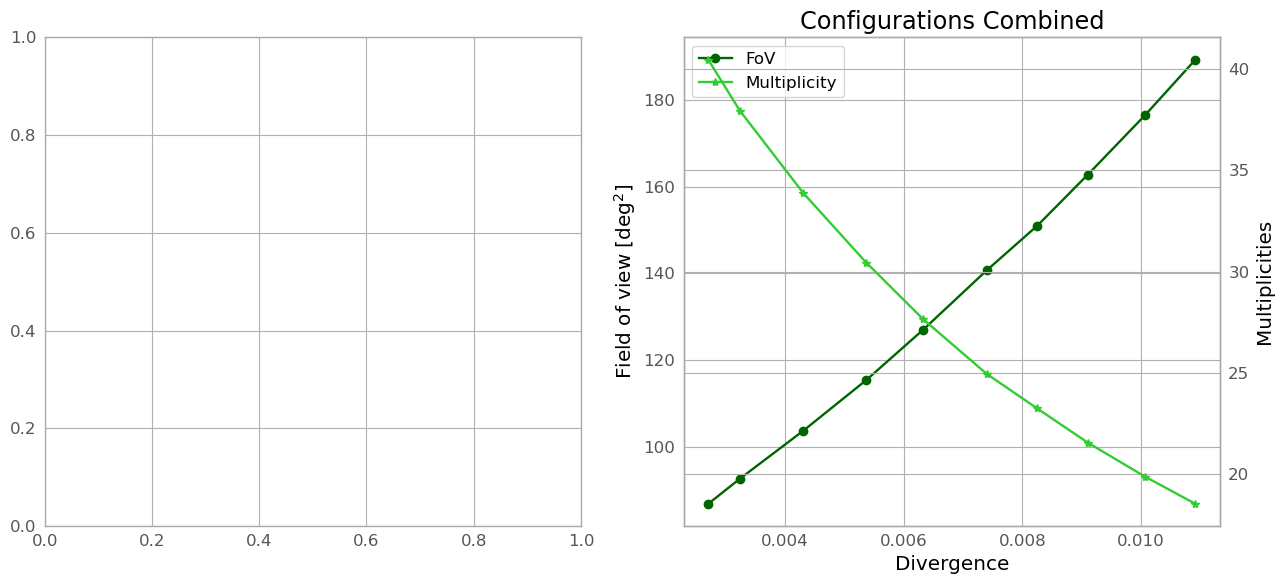

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6)) 
# Plot Full Array
# Full Array with m_cut = 3
#l1=axes[0].plot(chosen_divergences, FoV_full_array, label='FoV', marker='o', color='darkgreen')
#ax2 = axes[0].twinx()
#l2=ax2.plot(chosen_divergences, multiplicity_full_array, label='Multiplicities',marker='*', color='limegreen')
#axes[0].set_title('Full Array m_cut 3')
#axes[0].set_xlabel('Divergence')
#axes[0].set_ylabel('Field of view (m > 3) [deg$^2$]')
#ax2.set_ylabel('Multiplicities (m>3)')
#axeslegend = l1+l2
#axes[0].legend(axeslegend, [l.get_label() for l in axeslegend])



#Plot the ones for subarray 1
l1=axes[1].plot(divergence_list,hFoV_combine, label='FoV',marker='o', color='darkgreen')
ax5=axes[1].twinx()
l2=ax5.plot(divergence_list, m_ave_combine, label='Multiplicity', marker='*', color='limegreen')
axes[1].set_title('Configurations Combined')
axes[1].set_xlabel('Divergence')
axes[1].set_ylabel('Field of view [deg$^2$]')
ax5.set_ylabel('Multiplicities')
axeslegend = l1+l2
axes[1].legend(axeslegend, [l.get_label() for l in axeslegend])
#Plot the ones for subarray 2

# Adjust layout
plt.tight_layout()
# Subarray 4
# Adjust layout
plt.show()

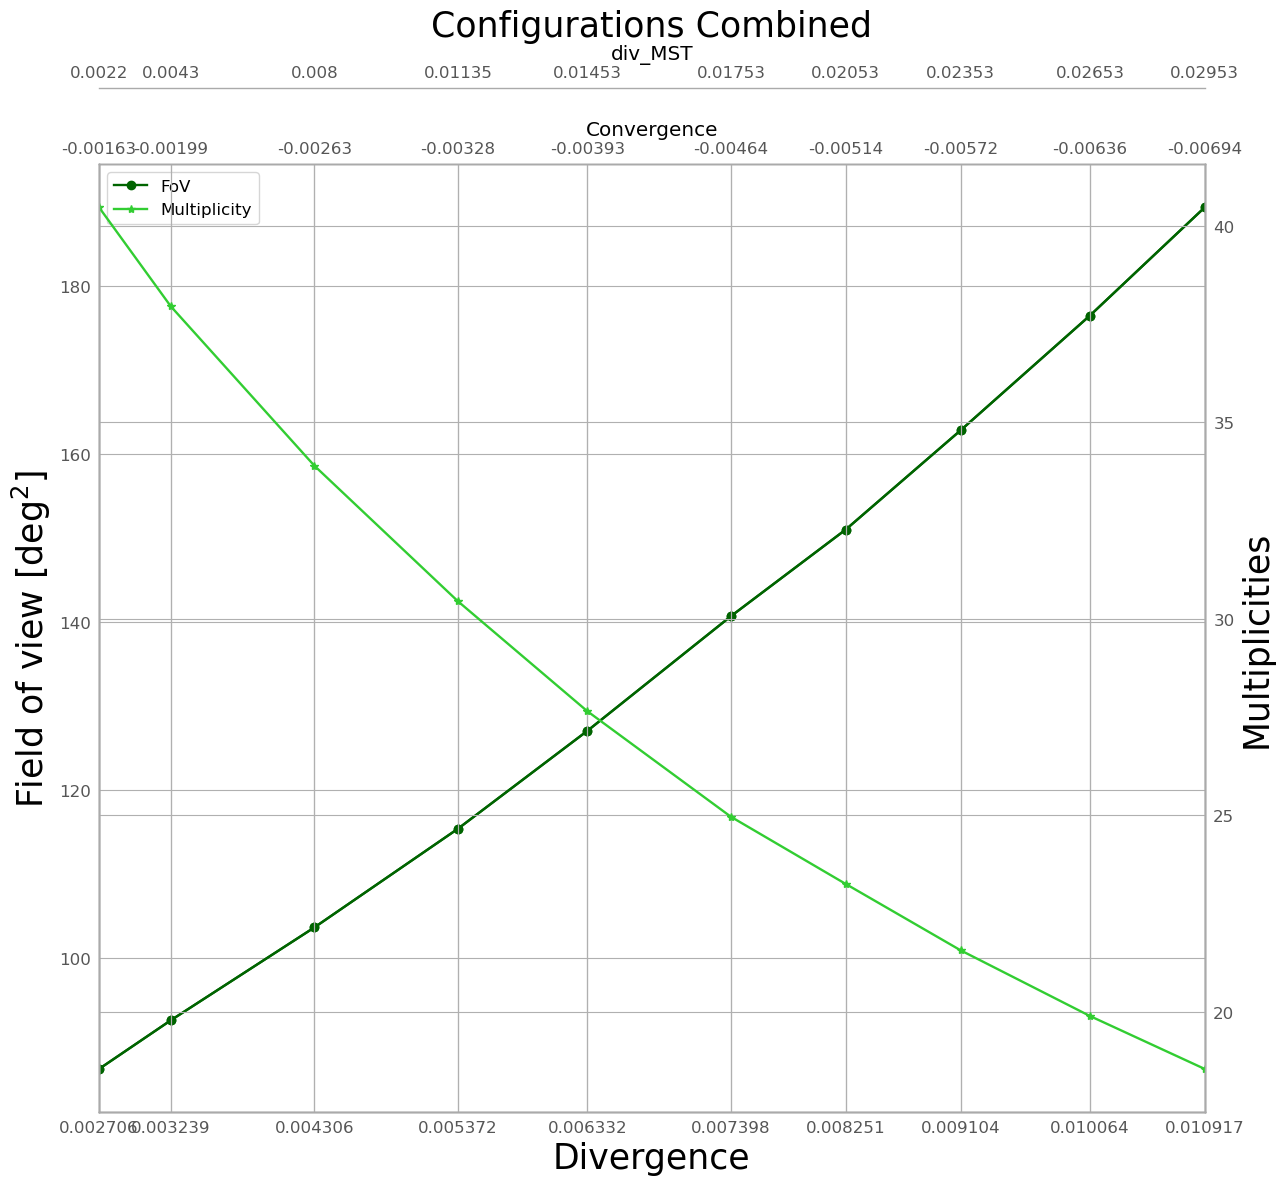

In [60]:
fig, axes = plt.subplots(1, 1, figsize=(13, 12))
ax = axes

# -----------------------------
# Primary plot on ax (left y-axis)
# -----------------------------
l1 = ax.plot(divergence_list, hFoV_combine, label='FoV', marker='o', color='darkgreen')
ax.set_xlabel('Divergence', fontsize = 25)
ax.set_ylabel('Field of view [deg$^2$]', fontsize = 25)
ax.set_title('Configurations Combined', fontsize = 25)
ax.set_xticks(divergence_list)
ax.set_xlim(min(divergence_list), max(divergence_list))

# Create a twin x-axis for Convergence (top)
ax_top1 = ax.twiny()
ax_top1.set_xlabel('Convergence')
ax_top1.set_xticks(divergence_list)  # Use the same positions
ax_top1.set_xticklabels(convergence_list)  # Direct mapping
ax_top1.set_xlim(ax.get_xlim())

# Create a second twin x-axis for div_MST (offset further up)
ax_top2 = ax.twiny()
ax_top2.spines["top"].set_position(("axes", 1.08))  # Adjust this factor as needed
ax_top2.set_xlabel('div_MST')
ax_top2.set_xticks(divergence_list)
ax_top2.set_xticklabels(div_MST)
ax_top2.set_xlim(ax.get_xlim())
l1=ax.plot(divergence_list,hFoV_combine, label='FoV',marker='o',color='darkgreen')
ax5=ax.twinx()
l2=ax5.plot(divergence_list, m_ave_combine, label='Multiplicity', marker='*', color='limegreen')
ax.set_title('Configurations Combined', fontsize = 25)
ax.set_xlabel('Divergence')
ax.set_ylabel('Field of view [deg$^2$]')
ax5.set_ylabel('Multiplicities', fontsize = 25)
axeslegend = l1+l2
ax.legend(axeslegend, [l.get_label() for l in axeslegend])
plt.tight_layout()
plt.show()

In [61]:
print(SST_config_conv.barycenter)

[-1.10000000e-01 -1.89478063e-14  3.12916667e+01]


In [62]:
print(SST_config_div.barycenter)

[-1.15571429  0.         24.59571429]


In [63]:
print(full_array_config_SST.barycenter)

[-0.67307692  0.         27.68615385]


6it [00:01,  5.93it/s]
7it [00:01,  5.92it/s]
4it [00:00,  5.79it/s]
6it [00:00,  6.07it/s]


12.615353396701982


7it [00:01,  6.04it/s]
4it [00:00,  6.32it/s]


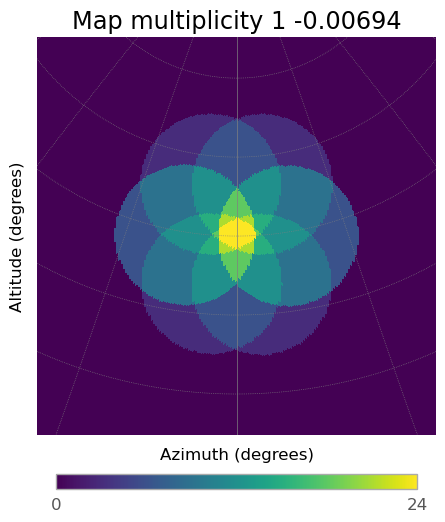

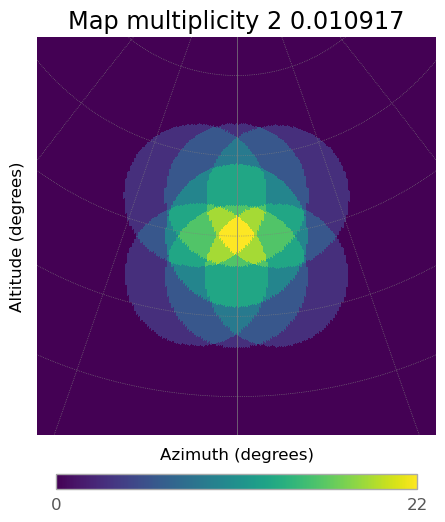

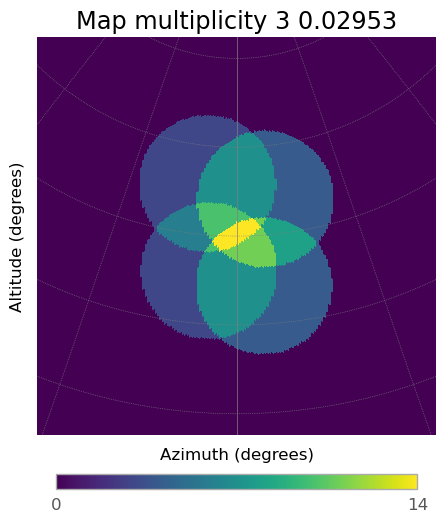

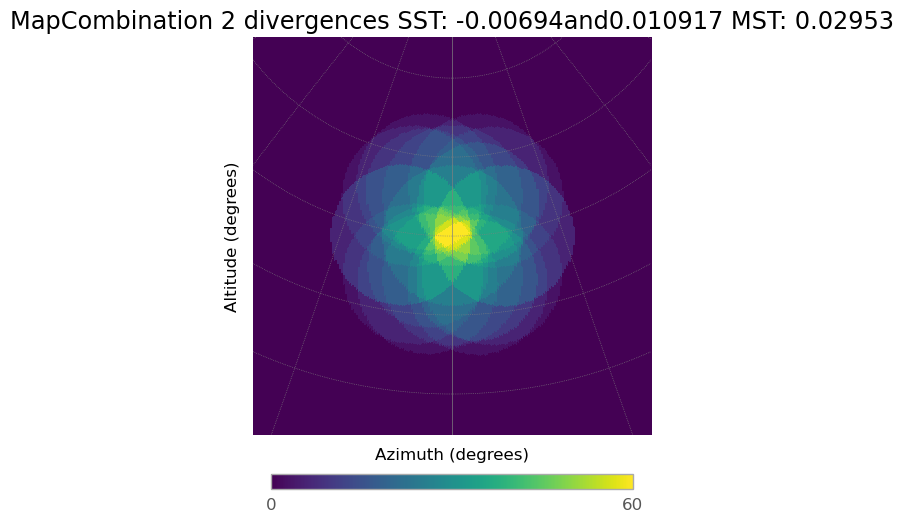

In [64]:
SST_config_conv.multiplicity_plot_3_config(array_2=SST_config_div,array_3=config_MST, subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3= number_of_telescopes_subarray_1)

In [65]:
# it works becauase here I am seeing what part is each!

In [66]:
SST_config_conv.combiantion_of_FoV(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST,subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1, m_cut=45)


6it [00:00,  6.27it/s]
7it [00:01,  5.21it/s]
4it [00:00,  5.78it/s]
/Users/macbook/miniconda3/envs/divtel/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/macbook/miniconda3/envs/divtel/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


(6.360272155115873, 54.37731958762887)

In [67]:
i=0
hFoV_graph=[]
multiplicities=[]
config_MST.divergent_pointing(div_MST[i],complete_array =combination_MST_SSTaz=0,alt=70)
SST_config_conv.divergent_pointing_2_div(complete_array=combination_MST_SST,tel_group_2=SST_config_div, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
#full_array.divergent_pointing(div=0.001, az=0, alt=70)

for j in range(60):
    hFoV_graph.append(SST_config_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST,subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1, m_cut=j)
[0])
    multiplicities.append(j+1)
plt.figure(figsize=(8, 6)) 
plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen')
plt.xlabel("Multiplicities")
plt.ylabel("hFoV[$deg^2$]")
plt.title(f"div_MST:{div_MST[i]}, conv_SST:{conv_SST[i]}, div_SST:{div_SST[i]}")
plt.grid(axis='y', alpha=0.4)
plt.show()   



SyntaxError: invalid syntax (1574617463.py, line 4)

In [ ]:
i=1
hFoV_graph=[]
multiplicities=[]
config_MST.divergent_pointing(div_MST[i],complete_array=combination_MST_SST, az=0,alt=70)
SST_config_conv.divergent_pointing_2_div(complete_array=combination_MST_SST,tel_group_2=SST_config_div, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
#full_array.divergent_pointing(div=0.001, az=0, alt=70)

for j in range(60):
    hFoV_graph.append(SST_config_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST,subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1, m_cut=j)
[0])
    multiplicities.append(j+1)
plt.figure(figsize=(8, 6)) 
plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen')
plt.xlabel("Multiplicities")
plt.ylabel("hFoV[$deg^2$]")
plt.title(f"div_MST:{div_MST[i]}, conv_SST:{conv_SST[i]}, div_SST:{div_SST[i]}")
plt.grid(axis='y', alpha=0.4)
plt.show()   


In [ ]:
i=2
hFoV_graph=[]
multiplicities=[]
config_MST.divergent_pointing(div_MST[i],complete_array==combination_MST_SST, az=0,alt=70)
SST_config_conv.divergent_pointing_2_div(complete_array=combination_MST_SST,tel_group_2=SST_config_div, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
#full_array.divergent_pointing(div=0.001, az=0, alt=70)

for j in range(60):
    hFoV_graph.append(SST_config_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST,subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1, m_cut=j)
[0])
    multiplicities.append(j+1)
plt.figure(figsize=(8, 6)) 
plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen')
plt.xlabel("Multiplicities")
plt.ylabel("hFoV[$deg^2$]")
plt.title(f"div_MST:{div_MST[i]}, conv_SST:{conv_SST[i]}, div_SST:{div_SST[i]}")
plt.grid(axis='y', alpha=0.4)
plt.show()   


In [ ]:
i=3
hFoV_graph=[]
multiplicities=[]
config_MST.divergent_pointing(div_MST[i], complete_array=combination_MST_SST, az=0,alt=70)
SST_config_conv.divergent_pointing_2_div(complete_array=combination_MST_SST,tel_group_2=SST_config_div, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
#full_array.divergent_pointing(div=0.001, az=0, alt=70)

for j in range(60):
    hFoV_graph.append(SST_config_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST,subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1, m_cut=j)
[0])
    multiplicities.append(j+1)
plt.figure(figsize=(8, 6)) 
plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen')
plt.xlabel("Multiplicities")
plt.ylabel("hFoV[$deg^2$]")
plt.title(f"div_MST:{div_MST[i]}, conv_SST:{conv_SST[i]}, div_SST:{div_SST[i]}")
plt.grid(axis='y', alpha=0.4)
plt.show() 

In [ ]:
i=9
hFoV_graph=[]
multiplicities=[]
config_MST.divergent_pointing(div_MST[i],complete_array==combination_MST_SST, az=0,alt=70)
SST_config_conv.divergent_pointing_2_div(complete_array=combination_MST_SST,tel_group_2=SST_config_div, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
#full_array.divergent_pointing(div=0.001, az=0, alt=70)

for j in range(60):
    hFoV_graph.append(SST_config_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST,subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1, m_cut=j)
[0])
    multiplicities.append(j+1)
plt.figure(figsize=(8, 6)) 
plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen')
plt.xlabel("Multiplicities")
plt.ylabel("hFoV[$deg^2$]")
plt.title(f"div_MST:{div_MST[i]}, conv_SST:{conv_SST[i]}, div_SST:{div_SST[i]}")
plt.grid(axis='y', alpha=0.4)
plt.show() 

In [ ]:
SST_config_div

In [ ]:
for i in range(10):
    hFoV_graph=[]
    multiplicities=[]
    config_MST.divergent_pointing(div_MST[i],complete_array=combination_MST_SST ,az=0,alt=70)
    SST_config_conv.divergent_pointing_2_div(complete_array=combination_MST_SST,tel_group_2=SST_config_div, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
#full_array.divergent_pointing(div=0.001, az=0, alt=70)

    for j in range(60):
        hFoV_graph.append(SST_config_conv.combiantion_of_FoV_with_m_cut_equal_to(number_of_arrays=3, array_2=SST_config_div, array_3=config_MST,subarray_mult_1=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1, m_cut=j)
[0])
        multiplicities.append(j+1)
    plt.figure(figsize=(8, 6)) 
    plt.bar(multiplicities, np.array(hFoV_graph).flatten(), color='limegreen')
    plt.xlabel("Multiplicities")
    plt.ylabel("hFoV[$deg^2$]")
    plt.title(f"MST div: {div_MST[i]}; SST div: {div_SST[i]}; SST conv: {conv_SST[i]}")
    plt.grid(axis='y', alpha=0.4)
    plt.show()   





The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations[-5.78333333  0.         29.18333333]
The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334
the barycenter for the calculations of the second divergence[-5.78333333  0.         29.18333333]
1.221718628000376 rad
-0.0 rad
1.2107405190700038 rad
-0.030769570454969013 rad
1.2108877093864527 rad
0.030769570454969013 rad
1.2105866917721522 rad
-0.0 rad
1.2321952511351593 rad
0.032859792892439746 rad
1.231900409665488 rad
-0.032859792892439746 rad
1.2325533043954682 rad
-0.0 rad


6it [00:01,  5.45it/s]
7it [00:01,  6.09it/s]
4it [00:00,  5.77it/s]
6it [00:01,  5.87it/s]
7it [00:01,  6.32it/s]
4it [00:00,  5.68it/s]
6it [00:01,  5.47it/s]
7it [00:01,  5.82it/s]
4it [00:00,  6.02it/s]
6it [00:00,  6.06it/s]
7it [00:01,  6.24it/s]
4it [00:00,  6.20it/s]
6it [00:00,  6.16it/s]
7it [00:01,  6.12it/s]
4it [00:00,  6.02it/s]
6it [00:00,  6.15it/s]
7it [00:01,  5.93it/s]
4it [00:00,  5.92it/s]
6it [00:01,  5.74it/s]
7it [00:01,  5.82it/s]
4it [00:00,  5.54it/s]
6it [00:01,  5.07it/s]
7it [00:01,  6.25it/s]
4it [00:00,  5.76it/s]
6it [00:01,  5.45it/s]
7it [00:01,  6.39it/s]
4it [00:00,  6.28it/s]
6it [00:01,  5.64it/s]
7it [00:01,  5.62it/s]
4it [00:00,  6.02it/s]
6it [00:01,  5.80it/s]
7it [00:01,  5.66it/s]
4it [00:00,  5.77it/s]
4it [00:00,  5.98it/s]

In [ ]:
for i in range(10):
    config_MST.divergent_pointing(div_MST[i], complete_array=combination_MST_SST, az=0,alt=70)
    SST_config_conv.divergent_pointing_2_div(tel_group_2=SST_config_div, complete_array=combination_MST_SST, div1=conv_SST[i], div2=div_SST[i], az=0, alt=70)
    SST_config_conv.combination_bar_graph_av_mult_MST_and_SST(array_2=SST_config_div, array_3=config_MST,subarray_mult=number_of_telescopes_config_SST_first_half, subarray_mult_2=number_of_telescopes_config_SST_second_half, subarray_mult_3=number_of_telescopes_subarray_1)
    